In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import json

from tqdm import tqdm
from pathlib import Path

## 데이터 확인

In [2]:
ROOT_DIR = Path(r".") #파일 경로
with open(ROOT_DIR/'split_stay_id.json', 'r') as f:
    splits_info = json.load(f)

df = pd.read_csv(ROOT_DIR/'released_df.csv.gz', compression='gzip')

display(df)
print(splits_info.keys())

,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death
0,00:00,Age,54.0,132539,1,5,-1,0
1,00:00,Gender,0.0,132539,1,5,-1,0
2,00:00,Height,NaN,132539,1,5,-1,0
3,00:00,ICUType,4.0,132539,1,5,-1,0
4,00:00,Weight,NaN,132539,1,5,-1,0
...,...,...,...,...,...,...,...,...
5085005,47:27,DiasABP,47.0,163037,7,21,-1,0
5085006,47:27,HR,74.0,163037,7,21,-1,0
5085007,47:27,MAP,63.0,163037,7,21,-1,0
5085008,47:27,SysABP,99.0,163037,7,21,-1,0


dict_keys(['train', 'valid', 'test'])


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5085010 entries, 0 to 5085009
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   charttime          object 
 1   label              object 
 2   value              float64
 3   stay_id            int64  
 4   SOFA               int64  
 5   los                int64  
 6   Survival           int64  
 7   In-hospital_death  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 310.4+ MB


## 전처리

In [4]:
from functools import partial
from tqdm import tqdm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from typing import Callable, Union
from pandas.core.groupby import DataFrameGroupBy

pd.set_option('display.max_columns', None)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=pd.errors.DtypeWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-whitegrid')
cmap_name = 'plasma'

In [5]:
# charttime의 데이터타입을 Timedelta 타입으로 변경
df['charttime'] = pd.to_timedelta(df['charttime'] + ':00')

# 확인 (timedelta64[ns] 타입)
print(df['charttime'].dtype)
display(df.head())
display(df)
df.info()

timedelta64[ns]


,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death
0,0 days,Age,54.0,132539,1,5,-1,0
1,0 days,Gender,0.0,132539,1,5,-1,0
2,0 days,Height,NaN,132539,1,5,-1,0
3,0 days,ICUType,4.0,132539,1,5,-1,0
4,0 days,Weight,NaN,132539,1,5,-1,0


,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death
0,0 days 00:00:00,Age,54.0,132539,1,5,-1,0
1,0 days 00:00:00,Gender,0.0,132539,1,5,-1,0
2,0 days 00:00:00,Height,NaN,132539,1,5,-1,0
3,0 days 00:00:00,ICUType,4.0,132539,1,5,-1,0
4,0 days 00:00:00,Weight,NaN,132539,1,5,-1,0
...,...,...,...,...,...,...,...,...
5085005,1 days 23:27:00,DiasABP,47.0,163037,7,21,-1,0
5085006,1 days 23:27:00,HR,74.0,163037,7,21,-1,0
5085007,1 days 23:27:00,MAP,63.0,163037,7,21,-1,0
5085008,1 days 23:27:00,SysABP,99.0,163037,7,21,-1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5085010 entries, 0 to 5085009
Data columns (total 8 columns):
 #   Column             Dtype          
---  ------             -----          
 0   charttime          timedelta64[ns]
 1   label              object         
 2   value              float64        
 3   stay_id            int64          
 4   SOFA               int64          
 5   los                int64          
 6   Survival           int64          
 7   In-hospital_death  int64          
dtypes: float64(1), int64(5), object(1), timedelta64[ns](1)
memory usage: 310.4+ MB


In [6]:
#label 종류 전부 출력(확인차)
labels = sorted(df['label'].unique())
print(len(labels))
print(labels)
print(df['label'].value_counts())

41
['ALP', 'ALT', 'AST', 'Age', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH']
label
HR             662451
MAP            426092
SysABP         425439
DiasABP        425314
Urine          397332
Weight         372097
NISysABP       283574
NIDiasABP      283305
NIMAP          279114
Temp           251802
GCS            178582
RespRate       159120
FiO2            91355
MechVent        87762
pH              69794
PaCO2           66685
PaO2            66520
HCT             53443
K               42454
Platelets       41441
Creatinine      40708
BUN             40527
Mg              39718
Na              39691
HCO3            39666
Glucose         38159
WBC             37791
Lactate     

## static 데이터프레임 생성과 분석

In [7]:
import pandas as pd

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)



# 정적 변수로 쓸 label
static_labels = ['Age', 'Gender', 'Height', 'ICUType']

# 해당 label 필터링
static_long = df[df['label'].isin(static_labels)].copy()

# 혹시 동일 stay_id, 동일 label이 여러 번 있을 수도 있으니 charttime 기준으로 정렬 후 첫 값만 사용
static_long = static_long.sort_values(['stay_id', 'label', 'charttime'])
static_long = static_long.drop_duplicates(subset=['stay_id', 'label'], keep='first')

static_wide = static_long.pivot(index='stay_id', columns='label', values='value')
static_wide = static_wide.rename_axis(columns=None).reset_index()

# charttime이 0일 때의 Weight (입원 당시 체중)->중복값 있어서 참고만
admission_weight = df[(df['label'] == 'Weight') &
                      (df['charttime'] == pd.Timedelta('0 days 00:00:00'))].copy()

# 혹시 같은 stay_id에 0시 Weight가 여러 개면 첫번째 사용 
admission_weight = admission_weight.sort_values(['stay_id', 'charttime'])
admission_weight = admission_weight.drop_duplicates(subset=['stay_id'], keep='first')

# stay_id를 인덱스로, value를 'Weight' 컬럼명으로
admission_weight = (admission_weight
                    .set_index('stay_id')['value']
                    .rename('Admission Weight')
                    .reset_index())

outcome_cols = ['SOFA', 'los', 'Survival', 'In-hospital_death']
outcomes = (df
            .groupby('stay_id', as_index=False)[outcome_cols]
            .first())

static_df = outcomes.merge(static_wide, on='stay_id', how='left')

static_df = static_df.merge(admission_weight, on='stay_id', how='left')

cols_order = ['stay_id',
              'Age', 'Gender', 'Height', 'ICUType', 'Admission Weight',
              'SOFA', 'los', 'Survival', 'In-hospital_death']

# 실제 존재하는 것만 순서대로 남기기
cols_order = [c for c in cols_order if c in static_df.columns]
static_df = static_df[cols_order]

print(static_df.head())
print(static_df.shape)

   stay_id   Age  Gender  Height  ICUType  Admission Weight  SOFA  los  Survival  In-hospital_death
0   132539  54.0     0.0     NaN      4.0               NaN     1    5        -1                  0
1   132540  76.0     1.0   175.3      2.0              76.0     8    8        -1                  0
2   132541  44.0     0.0     NaN      3.0              56.7    11   19        -1                  0
3   132543  68.0     1.0   180.3      3.0              84.6     1    9       575                  0
4   132545  88.0     0.0     NaN      3.0               NaN     2    4       918                  0
(11514, 10)


In [8]:
# stay_id 중복 여부 확인
dup_ids = static_df['stay_id'][static_df['stay_id'].duplicated()].unique()
duplicate_rows = static_df[static_df['stay_id'].isin(dup_ids)]
print(duplicate_rows)
print("중복된 stay_id 개수:", len(dup_ids))

Empty DataFrame
Columns: [stay_id, Age, Gender, Height, ICUType, Admission Weight, SOFA, los, Survival, In-hospital_death]
Index: []
중복된 stay_id 개수: 0


## 데이터 정보 시각화

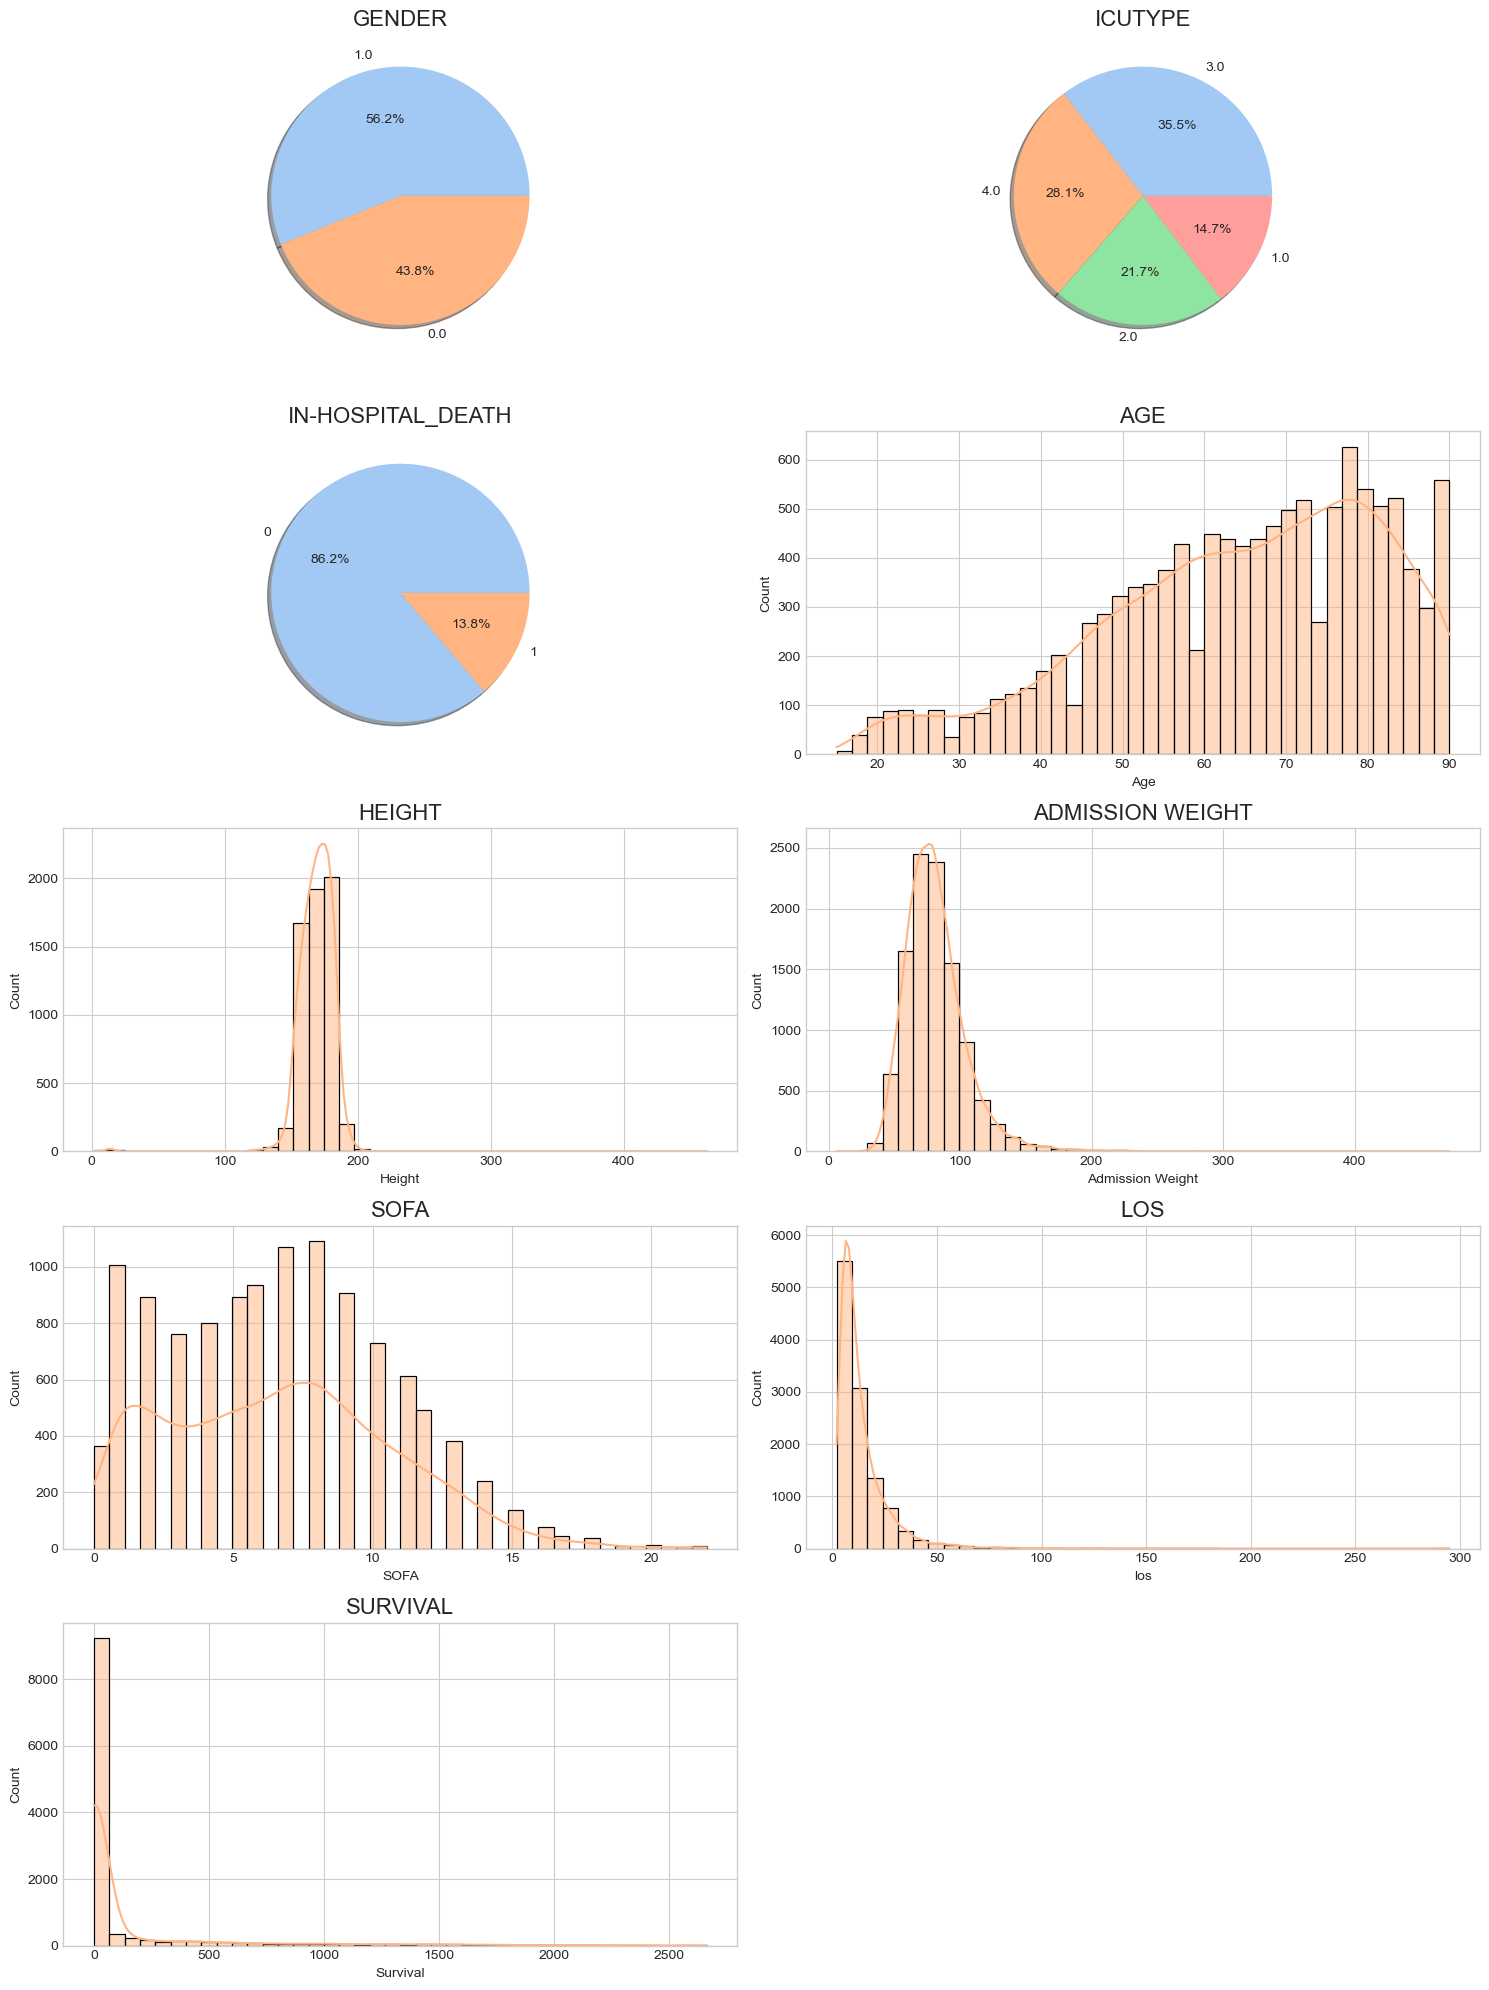

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 변수
categorical_cols = ['Gender', 'ICUType', 'In-hospital_death']
numeric_cols = ['Age', 'Height', 'Admission Weight', 'SOFA', 'los', 'Survival']

fig = plt.figure(figsize=(15, 20))

# 1) Categorical Variables → Pie Chart
for idx, col in enumerate(categorical_cols):
    ax = fig.add_subplot(5, 2, idx+1)
    ax.set_title(col.upper(), fontsize=16)

    tmp = static_df[col].value_counts(normalize=True)
    labels = tmp.index.astype(str)
    colors = sns.color_palette('pastel', len(tmp))

    ax.pie(tmp, labels=labels, autopct='%1.1f%%', colors=colors, shadow=True)

# 2) Numeric Variables → Histogram
for idx, col in enumerate(numeric_cols):
    ax = fig.add_subplot(5, 2, len(categorical_cols) + idx + 1)
    ax.set_title(col.upper(), fontsize=16)

    sns.histplot(static_df[col].dropna(), bins=40, kde=True, color=sns.color_palette("pastel")[1], ax=ax)

plt.tight_layout()
plt.show()

ALP mean frequency: 17.06 hr
ALT mean frequency: 17.12 hr
AST mean frequency: 17.09 hr
Albumin mean frequency: 17.45 hr
BUN mean frequency: 15.43 hr
Bilirubin mean frequency: 16.93 hr
Cholesterol mean frequency: 12.89 hr
Creatinine mean frequency: 15.38 hr
DiasABP mean frequency: 0.79 hr
FiO2 mean frequency: 2.97 hr
GCS mean frequency: 3.46 hr
Glucose mean frequency: 15.55 hr
HCO3 mean frequency: 15.69 hr
HCT mean frequency: 12.56 hr
HR mean frequency: 0.84 hr
K mean frequency: 14.09 hr
Lactate mean frequency: 8.17 hr
MAP mean frequency: 0.8 hr
MechVent mean frequency: 3.06 hr
Mg mean frequency: 14.6 hr
NIDiasABP mean frequency: 1.72 hr
NIMAP mean frequency: 1.71 hr
NISysABP mean frequency: 1.75 hr
Na mean frequency: 15.79 hr
PaCO2 mean frequency: 5.93 hr
PaO2 mean frequency: 5.94 hr
Platelets mean frequency: 15.35 hr
RespRate mean frequency: 1.03 hr
SaO2 mean frequency: 6.65 hr
SysABP mean frequency: 0.79 hr
Temp mean frequency: 3.08 hr
TroponinI mean frequency: 11.13 hr
TroponinT mea

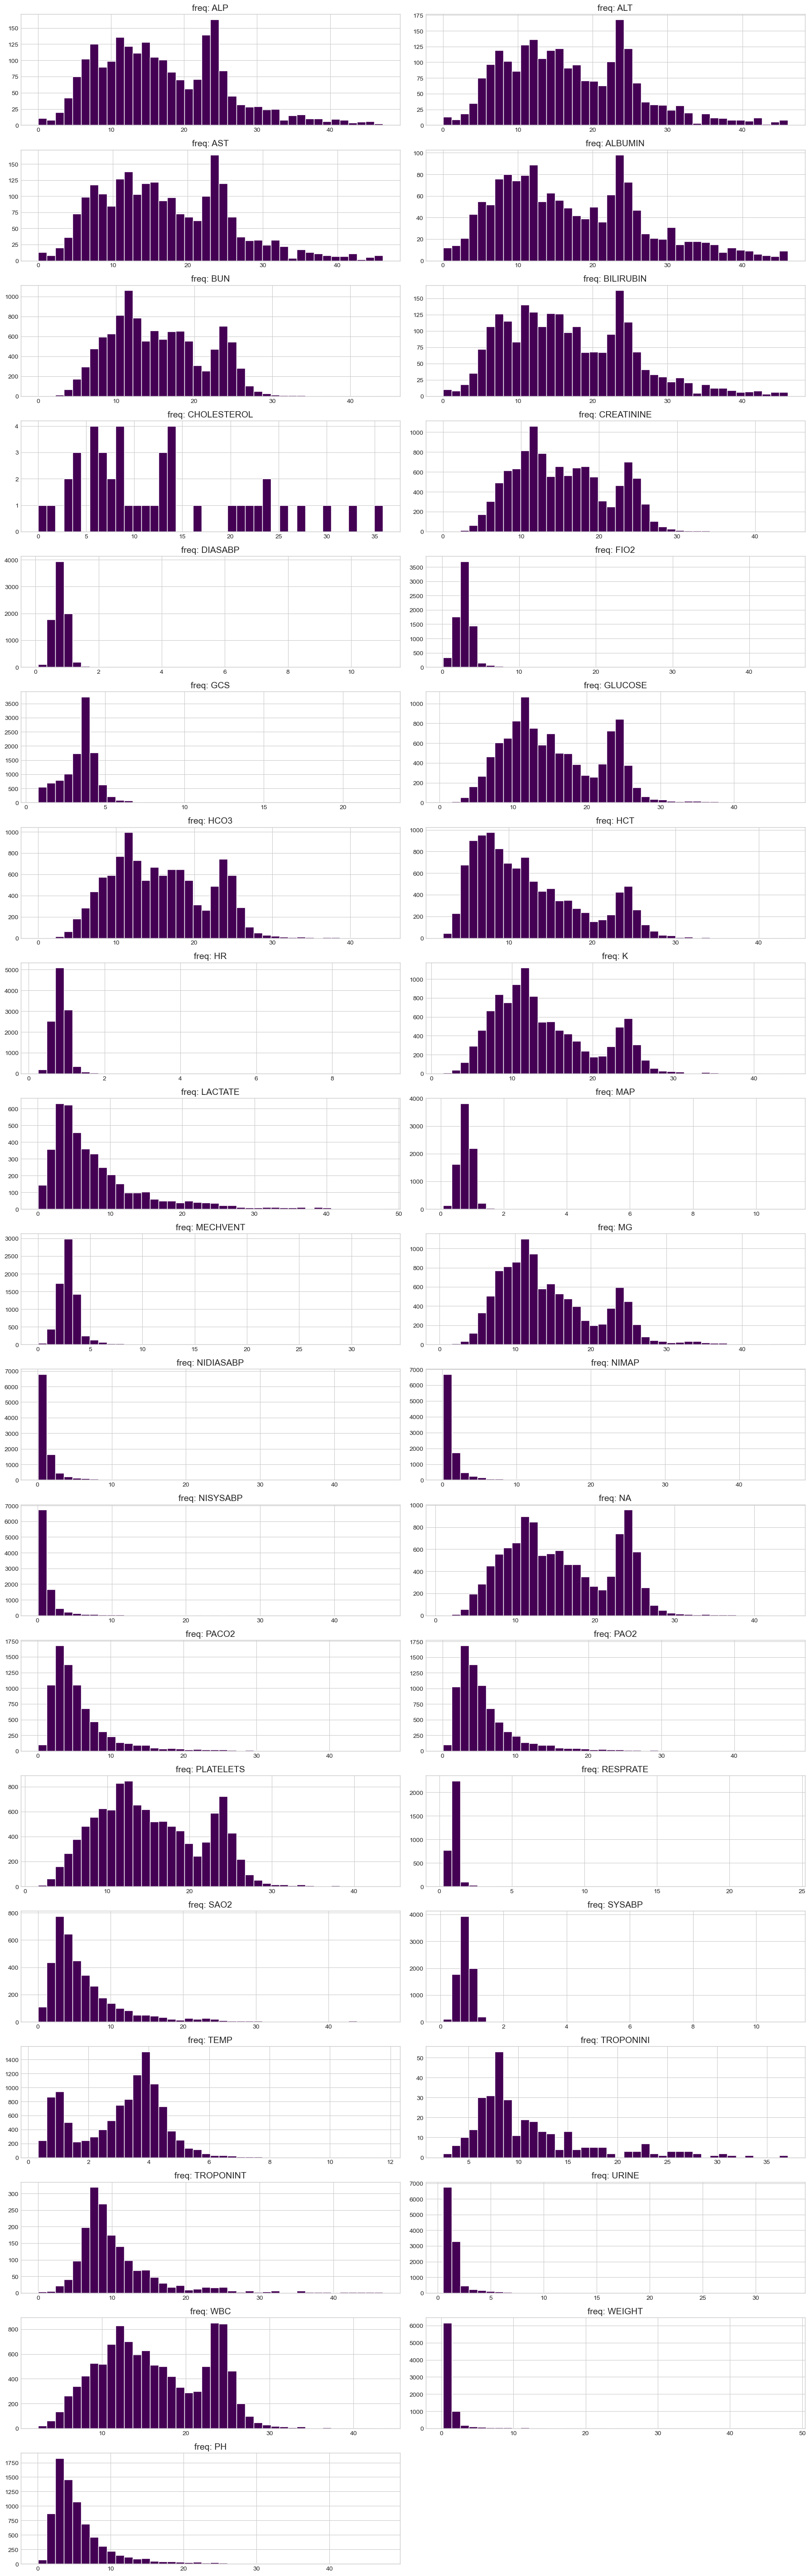

In [10]:
# frequency 계산과 시각화

dynamic_labels = [
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate',
    'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine',
    'WBC', 'Weight', 'pH'
]

# 동적 label만 미리 필터링
dyn_df = df[df['label'].isin(dynamic_labels)].copy()

freq_dict = {}

for lab in dynamic_labels:
    sub = dyn_df[dyn_df['label'] == lab].copy()
    
    freq_list = []
    for sid, g in sub.groupby('stay_id'):
        g = g.sort_values('charttime')
        t = g['charttime'].values
        
        if len(t) < 2:
            continue
        
        # charttime이 timedelta64[ns]이므로 시간(hour) 단위로 변환
        diffs = np.diff(t) / np.timedelta64(1, 'h')
        
        if len(diffs) > 0:
            freq_list.append(diffs.mean())
    
    freq_dict[lab] = np.array(freq_list)
    
for lab in dynamic_labels:
    arr = freq_dict[lab]
    if len(arr) == 0:
        print(f'{lab}: 측정 간격을 계산할 수 있는 stay_id가 없음')
    else:
        print(f'{lab} mean frequency: {round(arr.mean(), 2)} hr')
    print('=================')
cmap_name = 'viridis'  # 사용 colormap

# 1) 전체 변수에 대해 mean frequency 출력
for item in dynamic_labels:
    tmp = freq_dict[item]
    if len(tmp) == 0:
        print(f'{item}: 측정 간격 데이터 없음')
    else:
        print(f'{item} mean frequency: {round(tmp.mean(), 2)} hr')
    print('=============')

# 2) 전체 변수 히스토그램 시각화
n_items = len(dynamic_labels)
n_rows = (n_items + 1) // 2   # 2개씩 배치

fig = plt.figure(figsize=(18, n_rows * 3))

for idx, item in enumerate(dynamic_labels):
    tmp = freq_dict[item]
    ax = fig.add_subplot(n_rows, 2, idx+1)
    ax.set_title('freq: ' + item.upper(), size=14)

    if len(tmp) > 0:
        ax.hist(tmp, bins=40,
                color=plt.colormaps.get_cmap(cmap_name)(0),
                edgecolor='white')

plt.tight_layout()
plt.show()

#### **데이터 정합성, 결측치 검사-> 데이터에 맞게 해야함

In [11]:
'''import pandas as pd

# charttime == 0 AND label == "Weight" 만 필터링
w0 = df[(df['label'] == 'Weight') & (df['charttime'] == pd.Timedelta('0 days 00:00:00'))]

# stay_id 중복 여부 찾기
dup_weight_ids = w0['stay_id'][w0['stay_id'].duplicated()].unique()

print("0시 Weight가 2번 이상 기록된 stay_id 목록:")
print(dup_weight_ids)
print("총 개수:", len(dup_weight_ids))
duplicate_weights = w0[w0['stay_id'].isin(dup_weight_ids)]
print(duplicate_weights)'''
#중복 0시 weight 조사 


'import pandas as pd\n\n# charttime == 0 AND label == "Weight" 만 필터링\nw0 = df[(df[\'label\'] == \'Weight\') & (df[\'charttime\'] == pd.Timedelta(\'0 days 00:00:00\'))]\n\n# stay_id 중복 여부 찾기\ndup_weight_ids = w0[\'stay_id\'][w0[\'stay_id\'].duplicated()].unique()\n\nprint("0시 Weight가 2번 이상 기록된 stay_id 목록:")\nprint(dup_weight_ids)\nprint("총 개수:", len(dup_weight_ids))\nduplicate_weights = w0[w0[\'stay_id\'].isin(dup_weight_ids)]\nprint(duplicate_weights)'

## 이상치 처리

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

outlier_limits = {
    'Albumin': (0,60), 'ALP':(0,4000), 'ALT':(0,10000), 'AST':(0,10000),'Bilirubin':(0,60),
    'BUN':(0,250), 'Cholesterol':(0,1000), 'Creatinine':(0,66), 'DiasABP': (0, 375), 'Glucose': (0, 2200),
    'HCO3':(0,66), 'HCT':(0,100),  'HR': (0, 390), 'K':(0,15), 'Lactate':(0,33), 'Mg':(0,22),
    'MAP': (0,375), 'Na':(0,250), 'NIDiasABP':(0,300), 'NIMAP':(0,300), 'NISysABP':(0,400),
    'PaCO2':(0,220),'PaO2':(0,770), 'pH': (6.3, 10), 'Platelets':(0,2200), 'RespRate': (0, 330),
    'SaO2':(0,150),'SysABP': (0, 375),'Temp': (14, 46), 'TroponinI':(0,575),'Troponin-T':(0,24),
    'Urine':(0,2445), 'WBC':(0,1100)
}


# 이상치 제거에서 제외할 변수들
exclude_labels = ['FiO2', 'GCS', 'MechVent', 'Age', 'Gender', 'ICUType']

# 실제로 이상치 제거를 적용할 label 목록
target_labels = [lab for lab in df['label'].unique() if lab not in exclude_labels]

print("이상치 제거 대상 label 개수:", len(target_labels))
print("예시:", target_labels[:10])


이상치 제거 대상 label 개수: 35
예시: ['Height', 'Weight', 'HR', 'NIDiasABP', 'NIMAP', 'NISysABP', 'RespRate', 'Temp', 'Urine', 'HCT']


In [10]:
'''
3-시그마 기준 플롯 시각화

def plot_distributions_with_std(df, labels, std_thresh=3.0):

    n = len(labels)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3 * nrows),
                             squeeze=False)
    axes = axes.flatten()

    for ax, lab in zip(axes, labels):
        vals = df.loc[df['label'] == lab, 'value']
        vals = pd.to_numeric(vals, errors='coerce').dropna()
        if len(vals) == 0:
            ax.set_title(f"{lab} (no data)")
            continue

        mu, sd = vals.mean(), vals.std()

        sns.histplot(vals, bins=40, kde=True, ax=ax)
        ax.set_title(f"{lab}\nμ={mu:.2f}, σ={sd:.2f}", fontsize=11)

        # 평균 ± std_thresh*표준편차 기준선
        ax.axvline(mu, color='k', linestyle='-', linewidth=1)
        ax.axvline(mu + std_thresh * sd, color='r', linestyle='--', linewidth=1)
        ax.axvline(mu - std_thresh * sd, color='r', linestyle='--', linewidth=1)

    # 남는 subplot은 숨기기
    for j in range(len(labels), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# 이상치 제거 대상 변수들 모두 시각화
plot_distributions_with_std(df, target_labels, std_thresh=3)
'''


'\n3-시그마 기준 플롯 시각화\n\ndef plot_distributions_with_std(df, labels, std_thresh=3.0):\n\n    n = len(labels)\n    ncols = 4\n    nrows = int(np.ceil(n / ncols))\n\n    fig, axes = plt.subplots(nrows, ncols,\n                             figsize=(4 * ncols, 3 * nrows),\n                             squeeze=False)\n    axes = axes.flatten()\n\n    for ax, lab in zip(axes, labels):\n        vals = df.loc[df[\'label\'] == lab, \'value\']\n        vals = pd.to_numeric(vals, errors=\'coerce\').dropna()\n        if len(vals) == 0:\n            ax.set_title(f"{lab} (no data)")\n            continue\n\n        mu, sd = vals.mean(), vals.std()\n\n        sns.histplot(vals, bins=40, kde=True, ax=ax)\n        ax.set_title(f"{lab}\nμ={mu:.2f}, σ={sd:.2f}", fontsize=11)\n\n        # 평균 ± std_thresh*표준편차 기준선\n        ax.axvline(mu, color=\'k\', linestyle=\'-\', linewidth=1)\n        ax.axvline(mu + std_thresh * sd, color=\'r\', linestyle=\'--\', linewidth=1)\n        ax.axvline(mu - std_thresh * sd, col

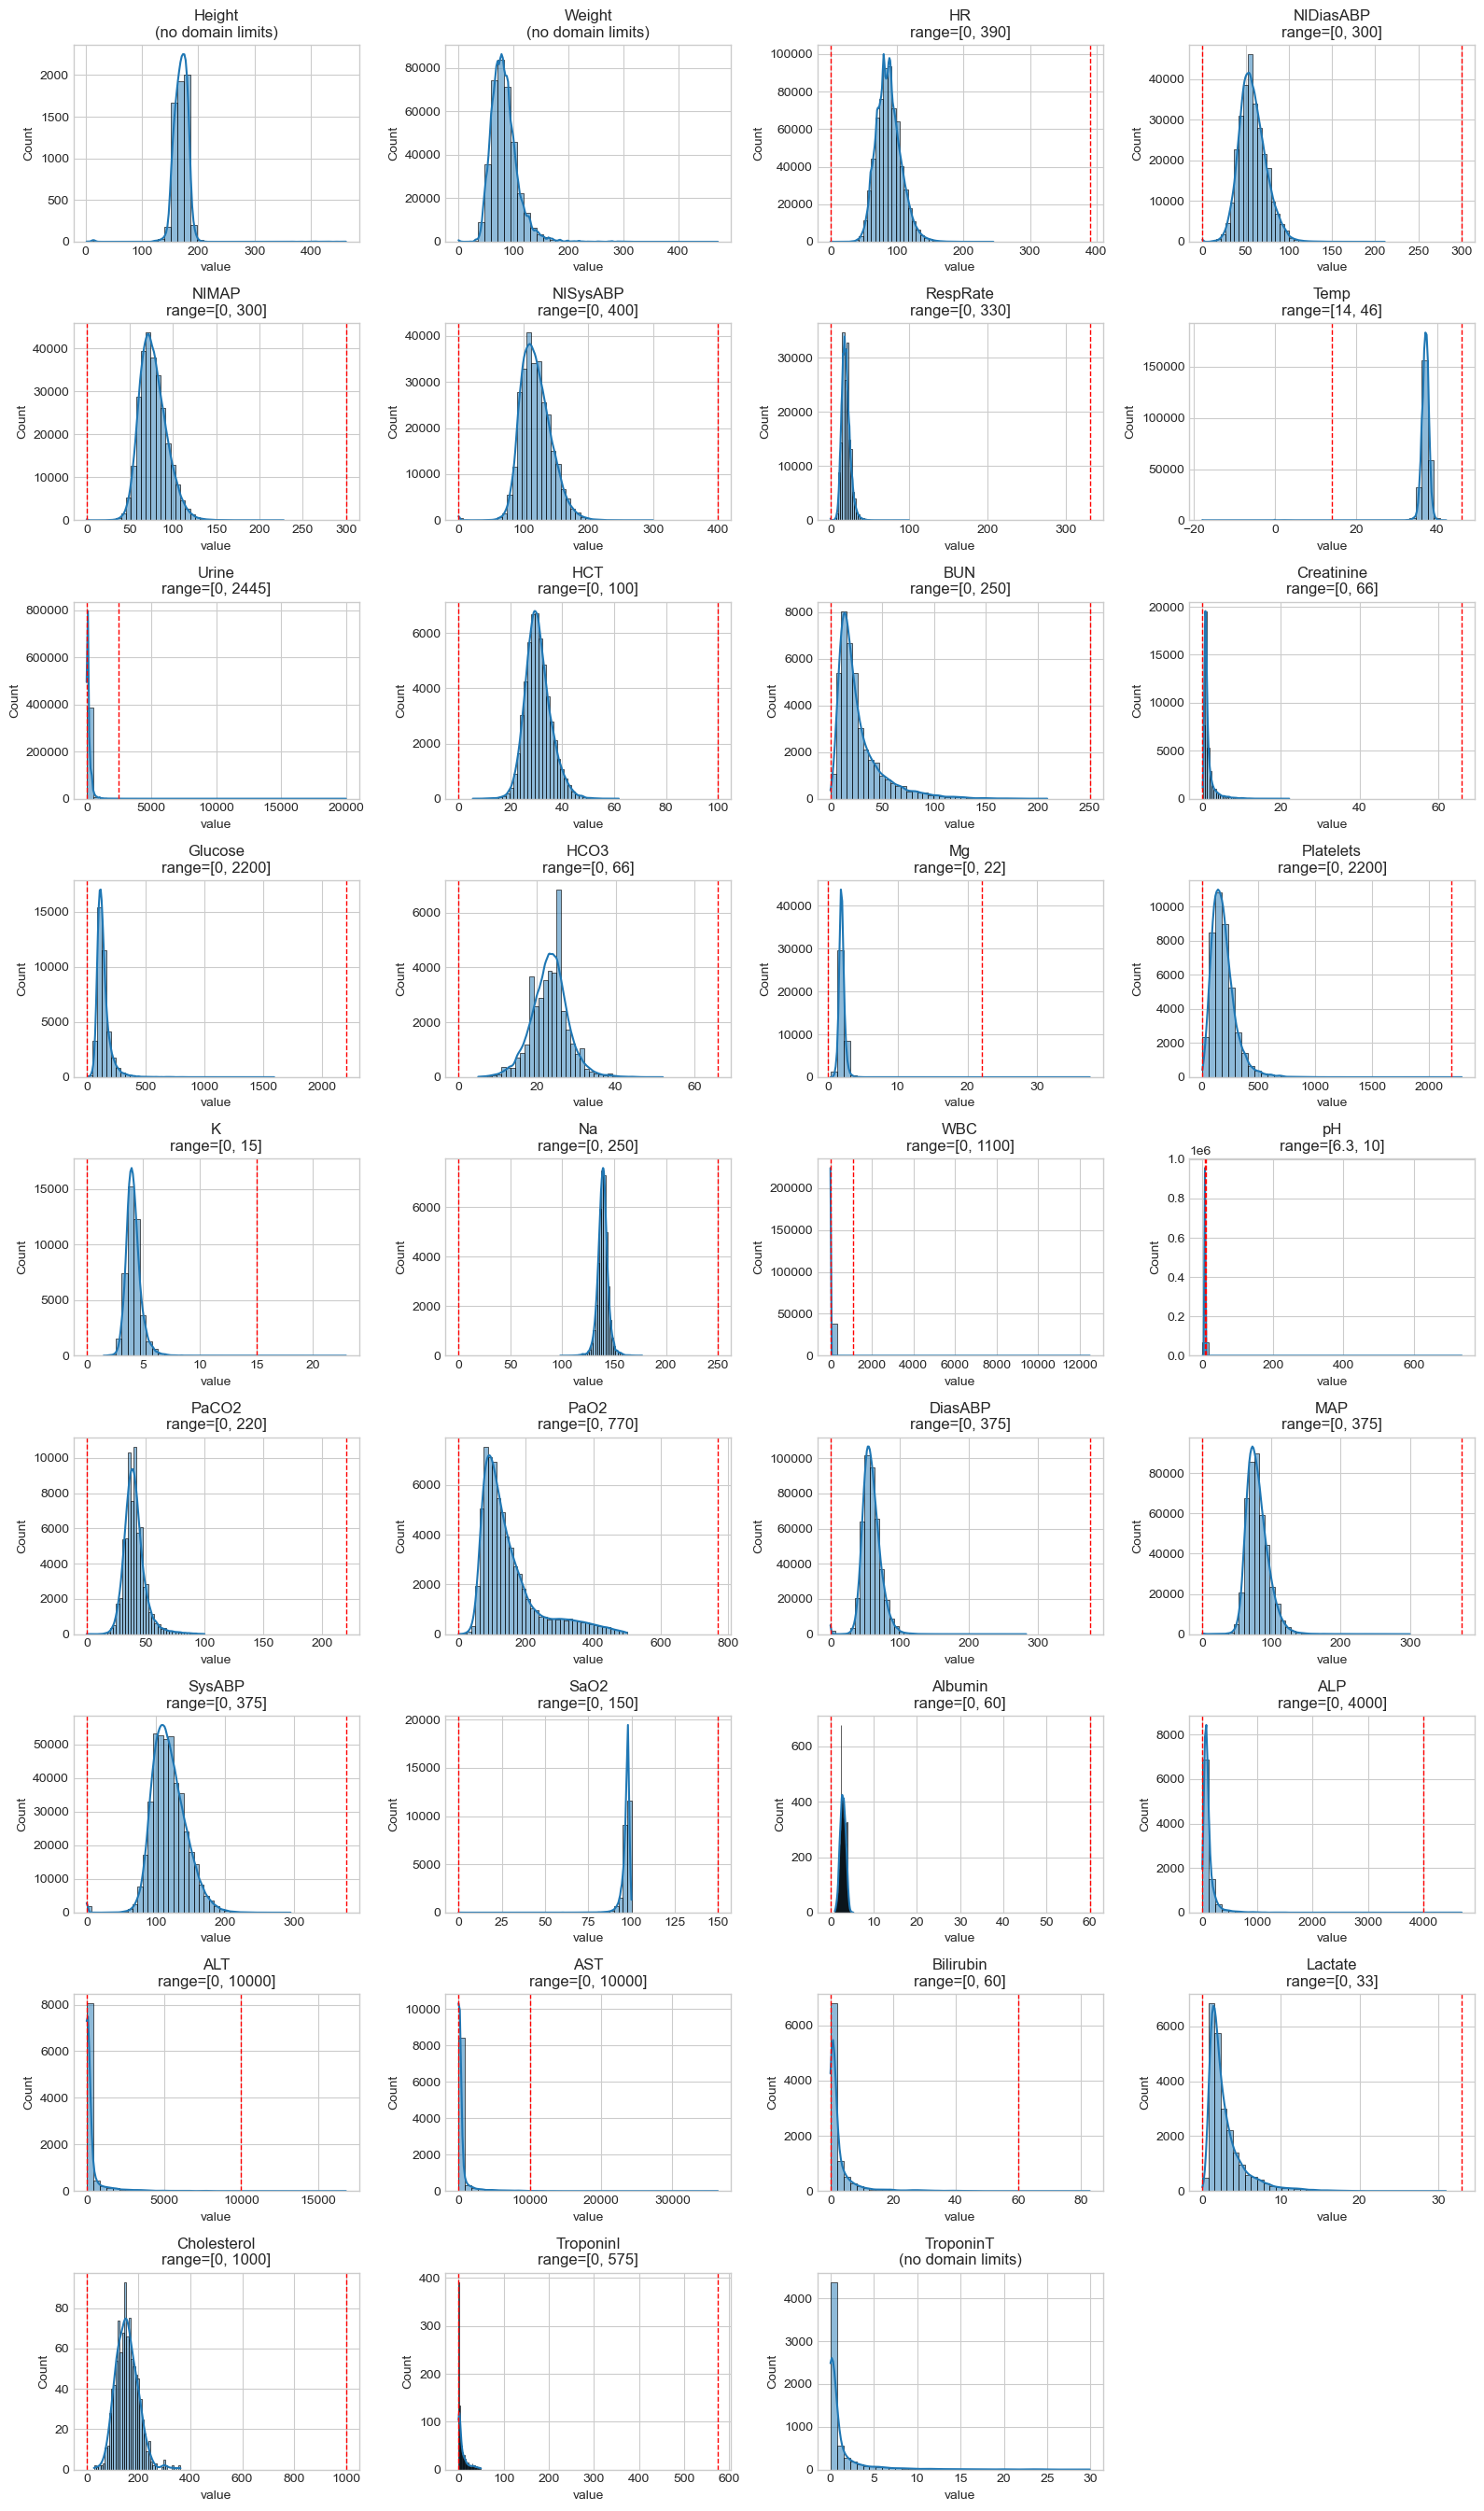

In [17]:
#domain 기준 그래프에 표시해 시각화

def plot_distributions_with_domain(df, labels, limits_dict):
    """
    df: 원본 데이터 (charttime, label, value, …)
    labels: 시각화할 label 리스트
    limits_dict: {label: (low, high)} 형태의 도메인 기준 dict
    """
    n = len(labels)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3 * nrows),
                             squeeze=False)
    axes = axes.flatten()

    for ax, lab in zip(axes, labels):
        vals = df.loc[df['label'] == lab, 'value']
        vals = pd.to_numeric(vals, errors='coerce').dropna()
        if len(vals) == 0:
            ax.set_title(f"{lab} (no data)")
            ax.axis('off')
            continue

        sns.histplot(vals, bins=40, kde=True, ax=ax)

        # 도메인 기준이 있으면 수직선 그리기
        if lab in limits_dict:
            low, high = limits_dict[lab]
            ax.axvline(low, color='r', linestyle='--', linewidth=1)
            ax.axvline(high, color='r', linestyle='--', linewidth=1)
            ax.set_title(f"{lab}\nrange=[{low}, {high}]")
        else:
            ax.set_title(f"{lab}\n(no domain limits)")

    # 남는 subplot은 숨기기
    for j in range(len(labels), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# 도메인 기준으로 시각화
plot_distributions_with_domain(df, target_labels, outlier_limits)


In [18]:
'''
3-시그마 기준 이상치 제거 코드

def remove_outliers_std(df, labels, std_thresh=3.0):

    outlier_idx = []

    for lab in labels:
        mask = df['label'] == lab
        if mask.sum() == 0:
            continue

        vals = pd.to_numeric(df.loc[mask, 'value'], errors='coerce')
        mu = vals.mean()
        sd = vals.std()

        if sd == 0 or np.isnan(sd):
            # 분산이 0이거나 값이 거의 없으면 스킵
            continue

        z = (vals - mu) / sd
        bad = z.abs() >= std_thresh

        outlier_idx.extend(df.loc[mask].index[bad])

    cleaned_df = df.drop(index=outlier_idx).reset_index(drop=True)
    return cleaned_df, outlier_idx
'''

"\n3-시그마 기준 이상치 제거 코드\n\ndef remove_outliers_std(df, labels, std_thresh=3.0):\n\n    outlier_idx = []\n\n    for lab in labels:\n        mask = df['label'] == lab\n        if mask.sum() == 0:\n            continue\n\n        vals = pd.to_numeric(df.loc[mask, 'value'], errors='coerce')\n        mu = vals.mean()\n        sd = vals.std()\n\n        if sd == 0 or np.isnan(sd):\n            # 분산이 0이거나 값이 거의 없으면 스킵\n            continue\n\n        z = (vals - mu) / sd\n        bad = z.abs() >= std_thresh\n\n        outlier_idx.extend(df.loc[mask].index[bad])\n\n    cleaned_df = df.drop(index=outlier_idx).reset_index(drop=True)\n    return cleaned_df, outlier_idx\n"

In [11]:
# domain 기준 이상치 제거 함수 

def remove_outliers_domain(df, limits_dict, exclude_labels=None):
    """
    df: 원본 데이터프레임 (tidy format: label, value, ...)
    limits_dict: {label: (low, high)} 형태의 도메인 기준 dict
    exclude_labels: 이상치 제거에서 제외할 label 리스트
    
    return:
        cleaned_df: 이상치 row 제거 후 데이터프레임
        outlier_indices: 제거된 row들의 index 리스트 (원본 df 기준)
    """
    if exclude_labels is None:
        exclude_labels = []

    outlier_mask = pd.Series(False, index=df.index)

    for lab, (low, high) in limits_dict.items():
        if lab in exclude_labels:
            continue

        mask_lab = (df['label'] == lab)
        if not mask_lab.any():
            continue

        vals = pd.to_numeric(df.loc[mask_lab, 'value'], errors='coerce')

        # 도메인 범위 벗어나면 이상치
        bad = (vals < low) | (vals > high)
        outlier_mask.loc[mask_lab] = outlier_mask.loc[mask_lab] | bad

    outlier_indices = df.index[outlier_mask].tolist()
    cleaned_df = df.drop(index=outlier_indices).reset_index(drop=True)

    return cleaned_df, outlier_indices

In [12]:
# domain 기준으로 이상치 제거

clean_df, outlier_idx = remove_outliers_domain(
    df, 
    limits_dict=outlier_limits, 
    exclude_labels=exclude_labels)

print(f"도메인 기준 이상치 제거 적용")
print(f"원래 행 개수: {df.shape[0]}")
print(f"제거된 행 개수: {len(outlier_idx)}")
print(f"제거 후 행 개수: {clean_df.shape[0]}")

도메인 기준 이상치 제거 적용
원래 행 개수: 5085010
제거된 행 개수: 653
제거 후 행 개수: 5084357


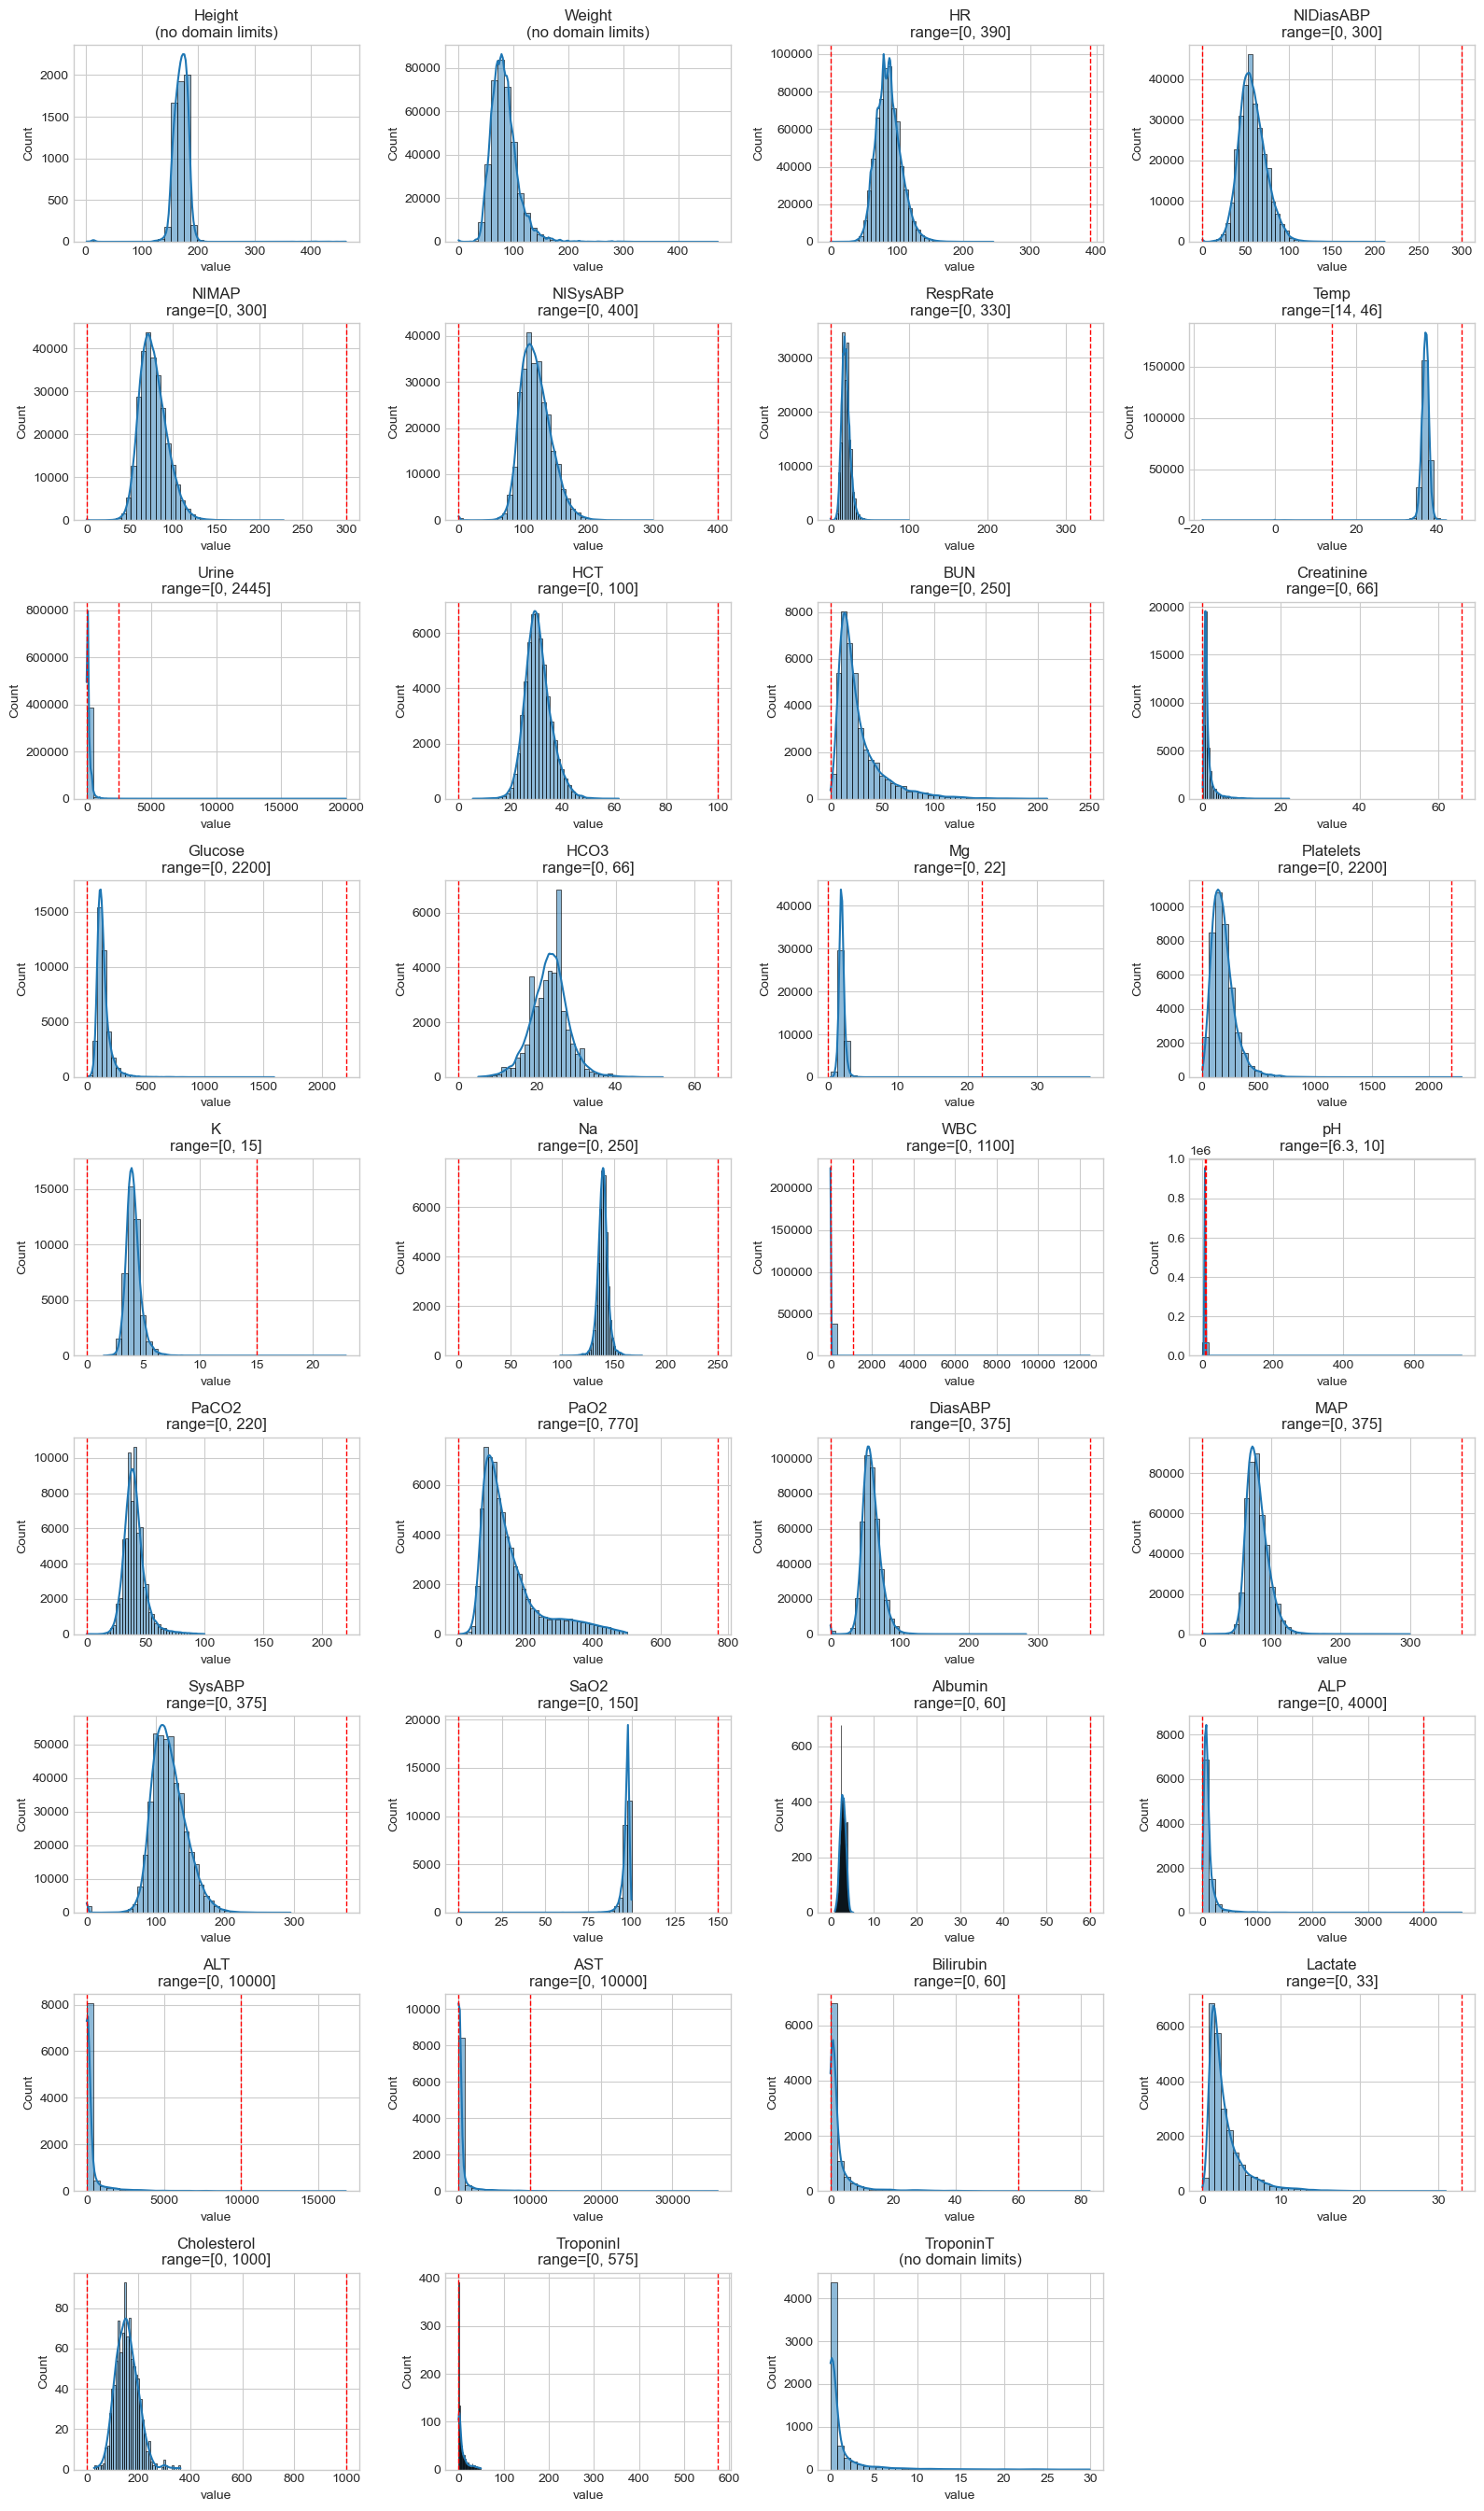

In [21]:
# 제거 후 plot 확인
plot_distributions_with_domain(df, target_labels, outlier_limits)

In [22]:
#이상치 제거 후 min/max 확인해기기

result = clean_df.groupby("label")["value"].agg(["min", "max"])
pd.set_option('display.max_rows', None)
print(result)

               min      max
label                      
ALP           8.00  3931.00
ALT           1.00  9975.00
AST           4.00  9970.00
Age          15.00    90.00
Albumin       1.00     5.30
BUN           0.00   209.00
Bilirubin     0.00    59.40
Cholesterol  28.00   362.00
Creatinine    0.10    22.10
DiasABP       0.00   283.00
FiO2          0.21     1.00
GCS           3.00    15.00
Gender        0.00     1.00
Glucose       8.00  1591.00
HCO3          5.00    52.00
HCT           5.50    61.80
HR            0.00   245.00
Height        1.80   462.30
ICUType       1.00     4.00
K             1.50    13.00
Lactate       0.00    31.00
MAP           0.00   300.00
MechVent      1.00     1.00
Mg            0.40    21.00
NIDiasABP     0.00   211.00
NIMAP         0.00   228.00
NISysABP      0.00   300.00
Na           98.00   177.00
PaCO2         0.00   100.00
PaO2          0.00   500.00
Platelets     5.00  2132.00
RespRate      0.00   100.00
SaO2          0.00   100.00
SysABP        0.00  

In [13]:
#입원 기간 외 기록 삭제-->삭제 데이터 없음

def time_error_handler_released(df: pd.DataFrame):
    df = df.copy()

    # charttime: timedelta → 분 단위로 변환
    df['_minutes_from_admit'] = df['charttime'] / np.timedelta64(1, 'm')

    # los(입원일수 × 24 × 60분)
    max_minutes = df['los'] * 24 * 60

    # 입원 기간 안에 포함되는 시간만 허용
    cond = df['_minutes_from_admit'] <= max_minutes

    return df[cond].drop(columns=['_minutes_from_admit']).reset_index(drop=True)
filtered_df = time_error_handler_released(clean_df)

print(f"원래 row 수: {clean_df.shape[0]}")
print(f"필터링 후 row 수: {filtered_df.shape[0]}")

원래 row 수: 5084357
필터링 후 row 수: 5084357


In [24]:
from IPython.display import display
display(clean_df.head(10))
display(clean_df.tail(10))

,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death
0,0 days 00:00:00,Age,54.00,132539,1,5,-1,0
1,0 days 00:00:00,Gender,0.00,132539,1,5,-1,0
2,0 days 00:00:00,Height,NaN,132539,1,5,-1,0
3,0 days 00:00:00,ICUType,4.00,132539,1,5,-1,0
4,0 days 00:00:00,Weight,NaN,132539,1,5,-1,0
5,0 days 00:07:00,GCS,15.00,132539,1,5,-1,0
6,0 days 00:07:00,HR,73.00,132539,1,5,-1,0
7,0 days 00:07:00,NIDiasABP,65.00,132539,1,5,-1,0
8,0 days 00:07:00,NIMAP,92.33,132539,1,5,-1,0
9,0 days 00:07:00,NISysABP,147.00,132539,1,5,-1,0


,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death
5084347,1 days 22:27:00,SysABP,95.0,163037,7,21,-1,0
5084348,1 days 22:57:00,DiasABP,43.0,163037,7,21,-1,0
5084349,1 days 22:57:00,HR,71.0,163037,7,21,-1,0
5084350,1 days 22:57:00,MAP,56.0,163037,7,21,-1,0
5084351,1 days 22:57:00,SysABP,85.0,163037,7,21,-1,0
5084352,1 days 23:27:00,DiasABP,47.0,163037,7,21,-1,0
5084353,1 days 23:27:00,HR,74.0,163037,7,21,-1,0
5084354,1 days 23:27:00,MAP,63.0,163037,7,21,-1,0
5084355,1 days 23:27:00,SysABP,99.0,163037,7,21,-1,0
5084356,1 days 23:27:00,Urine,30.0,163037,7,21,-1,0


## 타임스탬프 생성

In [14]:
def add_6h_timestamp(df):
    df = df.copy()

    # charttime(timedelta)를 "시간 단위 float"로 변환
    hours_from_admit = df['charttime'] / np.timedelta64(1, 'h')

    # 6시간 단위로 나눠서 슬롯 번호 계산 (0,1,2,...)
    ts = (hours_from_admit // 6).astype(int)

    # 혹시 48:00 같은 값이 있어도 timestamp는 0~7 사이로 제한
    ts = ts.clip(lower=0, upper=7)

    df['timestamp'] = ts
    return df

# 사용 예시
clean_df_with_ts = add_6h_timestamp(clean_df)

# 앞 10개, 뒤 10개 확인
from IPython.display import display
display(clean_df_with_ts.head(10))
display(clean_df_with_ts.tail(10))

,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death,timestamp
0,0 days 00:00:00,Age,54.00,132539,1,5,-1,0,0
1,0 days 00:00:00,Gender,0.00,132539,1,5,-1,0,0
2,0 days 00:00:00,Height,NaN,132539,1,5,-1,0,0
3,0 days 00:00:00,ICUType,4.00,132539,1,5,-1,0,0
4,0 days 00:00:00,Weight,NaN,132539,1,5,-1,0,0
5,0 days 00:07:00,GCS,15.00,132539,1,5,-1,0,0
6,0 days 00:07:00,HR,73.00,132539,1,5,-1,0,0
7,0 days 00:07:00,NIDiasABP,65.00,132539,1,5,-1,0,0
8,0 days 00:07:00,NIMAP,92.33,132539,1,5,-1,0,0
9,0 days 00:07:00,NISysABP,147.00,132539,1,5,-1,0,0


,charttime,label,value,stay_id,SOFA,los,Survival,In-hospital_death,timestamp
5084347,1 days 22:27:00,SysABP,95.0,163037,7,21,-1,0,7
5084348,1 days 22:57:00,DiasABP,43.0,163037,7,21,-1,0,7
5084349,1 days 22:57:00,HR,71.0,163037,7,21,-1,0,7
5084350,1 days 22:57:00,MAP,56.0,163037,7,21,-1,0,7
5084351,1 days 22:57:00,SysABP,85.0,163037,7,21,-1,0,7
5084352,1 days 23:27:00,DiasABP,47.0,163037,7,21,-1,0,7
5084353,1 days 23:27:00,HR,74.0,163037,7,21,-1,0,7
5084354,1 days 23:27:00,MAP,63.0,163037,7,21,-1,0,7
5084355,1 days 23:27:00,SysABP,99.0,163037,7,21,-1,0,7
5084356,1 days 23:27:00,Urine,30.0,163037,7,21,-1,0,7


## 데이터프레임 재구성

In [15]:
import numpy as np
import pandas as pd
from IPython.display import display

df = clean_df_with_ts.copy()

# 1. label 분류

continuous_labels = [
    'ALP', 'ALT','AST','Albumin','BUN','Bilirubin','Cholesterol',
    'Creatinine','DiasABP','FiO2','Glucose','HCO3','HCT','HR',
    'K', 'Lactate','MAP','Mg','NIDiasABP','NIMAP','NISysABP',
    'Na','PaCO2','PaO2','Platelets','RespRate','SaO2','SysABP',
    'Temp','TroponinI','TroponinT','Urine','WBC','Weight','pH', 'GCS'
]

binary_labels = ['MechVent']

categorical_labels = ['Gender', 'ICUType', 'Age', 'Height']  # 정적 변수

# 2. (stay_id, timestamp) 기준 피벗 함수

def make_pivot_binned(df: pd.DataFrame,
                      usage_labels: list,
                      aggfunc='mean',
                      value_col='value') -> pd.DataFrame:

    use = df[df['label'].isin(usage_labels)].copy()

    if use.empty:
        return pd.DataFrame(columns=['stay_id', 'timestamp'])

    pivot = use.pivot_table(
        index=['stay_id', 'timestamp'],
        columns='label',
        values=value_col,
        aggfunc=aggfunc
    ).reset_index().sort_values(['stay_id', 'timestamp'])

    if isinstance(aggfunc, (list, tuple)):
        new_cols = []
        for col in pivot.columns:
            if isinstance(col, tuple):
                if col[0] in ['stay_id', 'timestamp']:
                    new_cols.append(col[0])
                else:
                    new_cols.append(f"{col[0]}_{col[1]}")
            else:
                new_cols.append(col)
        pivot.columns = new_cols

    return pivot


# 3. 기준 타임라인 만들기: stay_id × timestamp(0~7)

RESAMPLING_SLOTS = 8 

stay_ids = np.sort(df['stay_id'].unique())
timestamps = np.arange(RESAMPLING_SLOTS)

base_df = (
    pd.MultiIndex.from_product(
        [stay_ids, timestamps],
        names=['stay_id', 'timestamp']
    )
    .to_frame(index=False)
)


# 4. 연속형 변수 피벗 (여러 집계값)

non_binary_aggs = ['mean', 'max', 'min', 'median', 'first', 'last']

cont_pivot = make_pivot_binned(
    df=df,
    usage_labels=continuous_labels,
    aggfunc=non_binary_aggs,
    value_col='value'
)


# 5. 이진 변수(MechVent) 피벗 (presence → max)

bin_pivot = make_pivot_binned(
    df=df,
    usage_labels=binary_labels,
    aggfunc='max',
    value_col='value'
)


# 6. 범주형 / 정적 변수(Gender, ICUType, GCS)는 stay-level 한 번만 추출

cat_df = (
    df[df['label'].isin(categorical_labels)]
      .pivot_table(
          index='stay_id',
          columns='label',
          values='value',
          aggfunc='first'
      )
      .reset_index()
)


# 7. outcome(SOFA, Survival, In-hospital_death, los) 추출

outcome_df = (
    df[['stay_id', 'SOFA', 'Survival', 'In-hospital_death', 'los']]
      .drop_duplicates(subset=['stay_id'])
)


# 8. 기준 타임라인(base_df)에 피벗 결과들 순서대로 병합

feat_df = base_df.merge(cont_pivot, on=['stay_id', 'timestamp'], how='left')
feat_df = feat_df.merge(bin_pivot,  on=['stay_id', 'timestamp'], how='left')

# outcome과 categorical은 stay-level이므로 stay_id 기준 병합
feat_df = feat_df.merge(outcome_df, on='stay_id', how='left')
final_df = feat_df.merge(cat_df, on='stay_id', how='left')


# 9. 결과 확인

pd.set_option('display.max_columns', None)
print(final_df.shape)
display(final_df.head(15))
display(final_df.tail(15))

(92112, 227)


,stay_id,timestamp,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,MechVent,SOFA,Survival,In-hospital_death,los,Age,Gender,Height,ICUType
0,132539,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,33.700000,71.285714,NaN,NaN,NaN,NaN,55.666667,80.890000,131.333333,NaN,NaN,NaN,NaN,18.857143,NaN,NaN,36.166667,NaN,NaN,231.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,33.7,80.0,NaN,NaN,NaN,NaN,65.0,92.33,157.0,NaN,NaN,NaN,NaN,20.0,NaN,NaN,37.8,NaN,NaN,900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,33.7,60.0,NaN,NaN,NaN,NaN,45.0,66.67,110.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,35.1,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,33.7,73.0,NaN,NaN,NaN,NaN,55.0,81.335,130.0,NaN,NaN,NaN,NaN,19.0,NaN,NaN,35.60,NaN,NaN,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,33.7,73.0,NaN,NaN,NaN,NaN,65.0,92.33,147.0,NaN,NaN,NaN,NaN,19.0,NaN,NaN,35.1,NaN,NaN,900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,33.7,73.0,NaN,NaN,NaN,NaN,45.0,66.67,110.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,37.8,NaN,NaN,170.0,NaN,NaN,NaN,NaN,1,-1,0,5,54.0,0.0,NaN,4.0
1,132539,1,NaN,NaN,NaN,NaN,13.0,NaN,NaN,0.8,NaN,NaN,15.0,205.0,26.0,33.500000,62.600000,4.4,NaN,NaN,1.5,51.000000,69.532000,106.600000,137.0,NaN,NaN,221.000000,15.200000,NaN,NaN,37.850000,NaN,NaN,88.000000,11.2,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,0.8,NaN,NaN,15.0,205.0,26.0,33.5,66.0,4.4,NaN,NaN,1.5,62.0,77.67,114.0,137.0,NaN,NaN,221.0,17.0,NaN,NaN,38.1,NaN,NaN,120.0,11.2,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,0.8,NaN,

,stay_id,timestamp,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,MechVent,SOFA,Survival,In-hospital_death,los,Age,Gender,Height,ICUType
92097,163035,1,NaN,NaN,NaN,NaN,39.0,2.6,NaN,2.40,67.125000,NaN,15.0,160.0,21.0,29.9,71.625000,5.50,1.950,81.250000,2.20,NaN,NaN,NaN,130.0,36.0,84.000000,42.0,NaN,NaN,111.250000,36.050000,NaN,NaN,13.000000,25.5,128.0,7.460000,NaN,NaN,NaN,NaN,39.0,2.6,NaN,2.4,71.0,NaN,15.0,160.0,21.0,29.9,78.0,5.5,2.0,86.0,2.2,NaN,NaN,NaN,130.0,36.0,84.0,42.0,NaN,NaN,120.0,36.4,NaN,NaN,15.0,25.5,128.0,7.46,NaN,NaN,NaN,NaN,39.0,2.6,NaN,2.4,62.0,NaN,15.0,160.0,21.0,29.9,60.0,5.5,1.9,74.0,2.2,NaN,NaN,NaN,130.0,36.0,84.0,42.0,NaN,NaN,101.0,35.7,NaN,NaN,10.0,25.5,128.0,7.46,NaN,NaN,NaN,NaN,39.0,2.6,NaN,2.40,67.5,NaN,15.0,160.0,21.0,29.9,72.0,5.50,1.95,81.5,2.20,NaN,NaN,NaN,130.0,36.0,84.0,42.0,NaN,NaN,112.0,36.05,NaN,NaN,14.0,25.5,128.0,7.460,NaN,NaN,NaN,NaN,39.0,2.6,NaN,2.4,69.0,NaN,15.0,160.0,21.0,29.9,78.0,5.5,1.9,85.0,2.2,NaN,NaN,NaN,130.0,36.0,84.0,42.0,NaN,NaN,117.0,35.7,NaN,NaN,14.0,25.5,128.0,7.46,NaN,NaN,NaN,NaN,39.0,2.6,NaN,2.4,71.0,NaN,15.0,160.0,21.0,29.9,72.0,5.5,2.0,86.0,2.2,NaN,NaN,NaN,130.0,36.0,84.0,42.0,NaN,NaN,120.0,36.1,NaN,NaN,10.0,25.5,128.0,7.46,NaN,9,96,0,71,71.0,1.0,NaN,1.0
92098,163035,2,NaN,NaN,NaN,NaN,44.0,NaN,NaN,2.70,68.857143,NaN,15.0,186.0,22.0,31.5,68.428571,5.50,NaN,82.857143,2.20,NaN,NaN,NaN,129.0,NaN,NaN,24.0,NaN,NaN,113.857143,35.200000,NaN,NaN,38.333333,23.9,128.0,NaN,NaN,NaN,NaN,NaN,44.0,NaN,NaN,2.7,72.0,NaN,15.0,186.0,22.0,31.5,71.0,5.5,NaN,88.0,2.2,NaN,NaN,NaN,129.0,NaN,NaN,24.0,NaN,NaN,121.0,35.2,

## 결측값 대치

In [16]:
def preprocess_missing_value(df: pd.DataFrame,
                             static_cols: list,
                             exclude_cols: list,
                             include_cols: list,
                             method: str = 'ffill_zero'):

    df = df.sort_values(['stay_id', 'timestamp']).copy()

    # 1) static
    static_df = df[static_cols]

    # 2) exclude -> 0으로 처리 
    excluded_df = df[exclude_cols].fillna(0)

    # 3) include → method별 처리
    base_cols = ['stay_id', 'timestamp'] + include_cols

    if method == 'zero':
        included_df = df[base_cols].fillna(0)

    elif method == 'ffill_zero':
        # [수정] groupby().ffill()은 stay_id가 사라져 다시 할당하도록 교수님 코드에서 수정함
        included_df = df[base_cols].groupby('stay_id').ffill()
        included_df['stay_id'] = df['stay_id']  # <---
        included_df = included_df.fillna(0)


    elif method == 'ffill_bfill':
        included_df = (
            df[base_cols]
            .groupby('stay_id', as_index=False)
            .ffill()
            .bfill()
        )

    elif method == 'interpolate':
        included_df = (
            df[base_cols]
            .groupby('stay_id', as_index=False)
            .apply(lambda g: g.sort_values('timestamp')
                               .interpolate(method='linear'))
            .reset_index(drop=True)
            .fillna(0)
        )

    elif method == 'mice':
        included_df = df[base_cols].copy()
        all_nan_cols = [c for c in included_df.columns
                        if included_df[c].notna().sum() == 0]
        included_df[all_nan_cols] = included_df[all_nan_cols].fillna(0)

        imputer = IterativeImputer(random_state=383)
        arr = imputer.fit_transform(included_df[include_cols])
        included_df[include_cols] = arr

    elif method == 'stay_mean':
        def causal_mean_impute(group: pd.DataFrame, value_cols: list):
            group = group.sort_values('timestamp')
            for col in value_cols:
                past_mean = (
                    group[col].shift(1)
                             .expanding(min_periods=1)
                             .mean()
                )
                group[col] = group[col].fillna(past_mean)
            return group

        included_df = df[base_cols].copy()
        included_df = (
            included_df
            .groupby('stay_id', group_keys=False)
            .apply(lambda g: causal_mean_impute(g, include_cols))
            .fillna(0)
        )

    else:
        raise ValueError('Please Select Missing Value Imputation Method.')

    included_df = included_df.sort_values(['stay_id', 'timestamp'])

    # 4) 병합
    res_df = pd.concat([static_df, excluded_df], axis=1)
    res_df = pd.merge(
        res_df,
        included_df,
        how='left',
        on=['stay_id', 'timestamp']
    )

    # 중복 컬럼 제거
    res_df = res_df.loc[:, ~res_df.columns.duplicated()]

    return res_df

In [17]:
df = final_df

static_cols = [
    'stay_id', 'timestamp',
    'SOFA', 'Survival', 'In-hospital_death', 'los', 'ICUType'
]

exclude_cols = ['MechVent', 'Height', 'Gender']  # binary 변수와 대치 불가능한 height -> NaN을 0로

include_cols = sorted(
    set(df.columns) - set(static_cols) - set(exclude_cols)
)

# ffill 후 남은 NaN은 0으로
preprocessed_df = preprocess_missing_value(
    df,
    static_cols=static_cols,
    exclude_cols=exclude_cols,
    include_cols=include_cols,
    method='ffill_zero'
)

In [18]:
print(preprocessed_df.shape)
display(preprocessed_df.head(20))
display(preprocessed_df.tail(20))

(92112, 227)


,stay_id,timestamp,SOFA,Survival,In-hospital_death,los,ICUType,MechVent,Height,Gender,Age,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH
0,132539,0,1,-1,0,5,4.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,65.0,92.33,147.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,35.1,0.0,0.0,900.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,45.0,66.67,110.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,37.8,0.0,0.0,170.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,80.0,0.0,0.0,0.0,0.0,65.0,92.33,157.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,37.8,0.0,0.0,900.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,15.0,0.0,0.0,33.700000,71.285714,0.0,0.0,0.000000,0.0,55.666667,80.890000,131.333333,0.0,0.00,0.0,0.000000,18.857143,0.0,0.000000,36.166667,0.0,0.0,231.666667,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,55.0,81.335,130.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,35.60,0.0,0.0,115.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,60.0,0.0,0.0,0.0,0.0,45.0,66.67,110.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,35.1,0.0,0.0,30.0,0.0,0.0,0.00
1,132539,1,1,-1,0,5,4.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.8,0.0,0.0,15.0,205.0,26.0,33.5,64.0,4.4,0.0,0.0,1.5,49.0,68.33,107.0,137.0,0.0,0.0,221.0,15.0,0.0,0.0,38.1,0.0,0.0,120.0,11.2,0.0,0.00,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.8,0.0,0.0,15.0,205.0,26.0,33.5,58.0,4.4,0.0,0.0,1.5,40.0,60.33,101.0,137.0,0.0,0.0,221.0,15.0,0.0,0.0,37.6,0.0,0.0,80.0,11.2,0.0,0.00,0.0,0.0,0.0,0.0

,stay_id,timestamp,SOFA,Survival,In-hospital_death,los,ICUType,MechVent,Height,Gender,Age,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH
92092,163034,4,10,-1,0,8,4.0,1.0,172.7,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.1,59.0,0.4,9.0,122.0,26.0,27.3,89.0,4.0,1.0,78.0,2.3,47.0,62.33,93.0,137.0,40.0,155.0,105.0,0.0,98.0,125.0,38.0,0.0,0.00,200.0,6.2,93.0,7.44,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.1,47.0,0.5,15.0,122.0,26.0,27.3,88.0,4.0,1.0,65.0,2.3,48.0,66.67,104.0,137.0,40.0,155.0,105.0,0.0,98.0,99.0,38.6,0.0,0.00,200.0,6.2,93.0,7.44,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.1,61.0,0.5,15.0,122.0,26.0,27.3,93.0,4.0,1.0,84.0,2.3,48.0,66.67,104.0,137.0,40.0,155.0,105.0,0.0,98.0,145.0,38.6,0.0,0.00,200.0,6.2,93.0,7.44,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.10,56.500000,0.450,13.0,122.0,26.0,27.3,89.000000,4.00,1.000,77.142857,2.30,47.500000,64.500000,98.500000,137.0,40.0,155.000000,105.0,0.0,98.0,128.000000,38.266667,0.0,0.00,180.000000,6.2,93.0,7.440000,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.10,59.0,0.45,15.0,122.0,26.0,27.3,89.0,4.00,1.00,80.0,2.30,47.5,64.50,98.5,137.0,40.0,155.0,105.0,0.0,98.0,129.5,38.20,0.0,0.00,200.0,6.2,93.0,7.440,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.1,47.0,0.4,9.0,122.0,26.0,27.3,85.0,4.0,1.0,65.0,2.3,47.0,62.33,93.0,137.0,40.0,155.0,105.0,0.0,98.0,99.0,38.0,0.0,0.00,140.0,6.2,93.0,7.44
92093,163034,5,10,-1,0,8,4.0,1.0,172.7,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.1,57.0,0.4,15.0,122.0,26.0,27.3,94.0,4.0,1.0,74.0,2.3,47.0,62.33,93.0,137.0,40.0,155.0,105.0,0.0,98.0,113.0,38.3,0.0,0.00,200.0,6.2,93.0,7.44,0.0,0.0,0.0,0.0,15.0,0.0,0.0,1.1,57.0,0.5,15.0,122.0,26.0,27.3,85.

In [19]:
#csv 저장
preprocessed_df.to_csv(r"preprocessed_df.csv", index=False)

## 라벨링

In [20]:
preprocessed_df = pd.read_csv(r"preprocessed_df.csv")

In [21]:
RESAMPLING_TIME = 6 * 60 * 60

def prediction_labeling(df: pd.DataFrame,
                        resampling_time: int,
                        window_hour: int,
                        new_label_name: str,
                        source_label_col: str):
    """
    df: input dataframe (must include timestamps)
    resampling_time: seconds per time slot (예: 6시간이면 6*60*60)
    window_hour: 앞으로 몇 시간 동안 label을 적용할 것인지 (예: 12)
    new_label_name: 새로 생성할 label 컬럼명
    source_label_col: 기준이 되는 현재 라벨 컬럼명
    
    예:
    - 각 timestamps row에서 향후 window_hour 동안 source_label_col이 1이면 new_label_name = 1
    """

    df = df.sort_values(['stay_id', 'timestamp']).copy()

    # resampling time(초)을 이용해 몇 step을 window로 볼 것인지 계산
    window_step = int(window_hour * 3600 / resampling_time)

    # 미래 구간의 label을 확인하기 위해 shift(-n)
    df[new_label_name] = df.groupby('stay_id')[source_label_col] \
                           .transform(lambda x: x.shift(-window_step).rolling(window_step).max())

    # 남은 NaN → 0
    df[new_label_name] = df[new_label_name].fillna(0)

    # int 타입으로 변환
    df[new_label_name] = df[new_label_name].astype(int)

    return df

In [22]:
# ARDS(급성 호흡곤란 증후군) 라벨링
# 진단 기준:
#  - 0 < PaO2/FiO2 ≤ 300
#  - MechVent = 1

def ards_annotation(df: pd.DataFrame):
    # PaO2/FiO2 계산
    ratio = df['mean_PaO2'] / df['mean_FiO2']

    # NaN, inf, -inf → 0 처리
    ratio = ratio.replace([np.inf, -np.inf], 0).fillna(0)

    df['pf_ratio'] = ratio

    # ARDS 진단 기준 적용
    # 진단 기준:
    #  - 0 < PaO2/FiO2 ≤ 300
    #  - MechVent = 1
    df['ards_now'] = np.where(
       (df['pf_ratio'] > 0) & (df['pf_ratio'] <= 300) & (df['MechVent'] == 1),
        1,
        0
    )

    return df

# 적용
preprocessed_df = ards_annotation(preprocessed_df)

# 향후 12시간 이내 ARDS 발생 여부를 prediction target으로 라벨링
# prediction_labeling(df, resampling_time, window_hours, new_label_name, source_label_col)
preprocessed_df = prediction_labeling(
    preprocessed_df,
    RESAMPLING_TIME,        # 6시간이면 6*60*60 초
    12,                     # 12시간 뒤까지
    'ards_next_12h',        # 새로 만들 타깃 라벨 이름
    'ards_now'              # 기준이 되는 현재 ARDS 여부
)

In [24]:
display(preprocessed_df.head(20))

,stay_id,timestamp,SOFA,Survival,In-hospital_death,los,ICUType,MechVent,Height,Gender,Age,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH,pf_ratio,ards_now,ards_next_12h
0,132539,0,1,-1,0,5,4.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,65.0,92.33,147.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,35.1,0.0,0.0,900.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,45.0,66.67,110.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,37.8,0.0,0.0,170.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,80.0,0.0,0.0,0.0,0.0,65.0,92.33,157.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,37.8,0.0,0.0,900.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,15.0,0.0,0.0,33.700000,71.285714,0.0,0.0,0.000000,0.0,55.666667,80.890000,131.333333,0.0,0.00,0.0,0.000000,18.857143,0.0,0.000000,36.166667,0.0,0.0,231.666667,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,55.0,81.335,130.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,35.60,0.0,0.0,115.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,60.0,0.0,0.0,0.0,0.0,45.0,66.67,110.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,35.1,0.0,0.0,30.0,0.0,0.0,0.00,0.000000,0,0
1,132539,1,1,-1,0,5,4.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.8,0.0,0.0,15.0,205.0,26.0,33.5,64.0,4.4,0.0,0.0,1.5,49.0,68.33,107.0,137.0,0.0,0.0,221.0,15.0,0.0,0.0,38.1,0.0,0.0,120.0,11.2,0.0,0.00,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.8,0.0,0.0,15.0,205.0,26.0,33.5,58.0,4.4,0.0,0.0,1.5,40.0,60.33,101.0,137.0,0.0,0.0,221.0,15.0,0.0,0.0,37

In [25]:
# 12시간 이내 발생 라벨 생성

def ards_prediction_labeling(df: pd.DataFrame,
                             resampling_time: int = 3600,
                             prediction_hour: int = 12,
                             label_col_name: str = 'ards_next_12h',
                             annot_col_name: str = 'ards_now'):
    """
    df : label을 만들 base dataframe
    resampling_time : 전처리 시 설정한 resampling time unit, 초 단위 (예: 6시간이면 21600)
    prediction_hour : '향후 몇 시간 이내'까지 ARDS 발생 여부를 볼지 (예: 12 = 12시간)
    label_col_name : 생성할 label column 이름 (예: 'ARDS_next_12h')
    annot_col_name : 현재 상태를 나타내는 binary 컬럼 이름
    """

    def _labeling(x: pd.DataFrame):
        # 같은 stay_id 내에서 timestamp 순서대로 정렬
        x = x.sort_values('timestamp').reset_index(drop=True)

        # 현재 row 기준으로, 다음 prediction_window개의 row 안에
        # annot_col_name(SIRS)이 1이 한 번이라도 나오면 label=1, 아니면 0
        x[label_col_name] = [
            1 if x[annot_col_name].iloc[idx+1 : idx+1+prediction_window].sum() >= 1 else 0
            for idx, _ in enumerate(x[annot_col_name])
        ]

        # 마지막 prediction_window개의 row는 미래 정보가 없으므로 버림
        return x.iloc[:-prediction_window, :]

    # '몇 개의 타임스텝을 미리 볼 것인지'를 index 단위로 변환
    # 예: resampling_time=6시간(21600초), prediction_hour=12 → prediction_window=2 (다음 2 스텝)
    global prediction_window
    prediction_window = int(60 * 60 * prediction_hour / resampling_time)

    labeled_df = df.groupby('stay_id', group_keys=False).apply(_labeling)

    return labeled_df

In [26]:
preprocessed_df = ards_prediction_labeling(
    preprocessed_df,
    resampling_time=21600,   
    prediction_hour=12,                # 향후 12시간
    label_col_name='ards_next_12h',    # 새로 만들 컬럼 이름
    annot_col_name='ards_now'          # 현재 ARDS 상태 컬럼
)

C:\quarto_\Temp\ipykernel_24448\1581198337.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  labeled_df = df.groupby('stay_id', group_keys=False).apply(_labeling)


In [27]:
display(preprocessed_df.head(20))
display(preprocessed_df.query("ards_next_12h == 1").head(10))

,stay_id,timestamp,SOFA,Survival,In-hospital_death,los,ICUType,MechVent,Height,Gender,Age,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH,pf_ratio,ards_now,ards_next_12h
0,132539,0,1,-1,0,5,4.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,65.0,92.33,147.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,35.1,0.0,0.0,900.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,73.0,0.0,0.0,0.0,0.0,45.0,66.67,110.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,37.8,0.0,0.0,170.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,80.0,0.0,0.0,0.0,0.0,65.0,92.33,157.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,37.8,0.0,0.0,900.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,15.0,0.0,0.0,33.700000,71.285714,0.0,0.0,0.000000,0.0,55.666667,80.890000,131.333333,0.0,0.00,0.0,0.000000,18.857143,0.0,0.000000,36.166667,0.0,0.0,231.666667,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.70,73.0,0.0,0.0,0.0,0.0,55.0,81.335,130.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,35.60,0.0,0.0,115.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,33.7,60.0,0.0,0.0,0.0,0.0,45.0,66.67,110.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,35.1,0.0,0.0,30.0,0.0,0.0,0.00,0.000000,0,0
1,132539,1,1,-1,0,5,4.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.8,0.0,0.0,15.0,205.0,26.0,33.5,64.0,4.4,0.0,0.0,1.5,49.0,68.33,107.0,137.0,0.0,0.0,221.0,15.0,0.0,0.0,38.1,0.0,0.0,120.0,11.2,0.0,0.00,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.8,0.0,0.0,15.0,205.0,26.0,33.5,58.0,4.4,0.0,0.0,1.5,40.0,60.33,101.0,137.0,0.0,0.0,221.0,15.0,0.0,0.0,3

,stay_id,timestamp,SOFA,Survival,In-hospital_death,los,ICUType,MechVent,Height,Gender,Age,first_ALP,first_ALT,first_AST,first_Albumin,first_BUN,first_Bilirubin,first_Cholesterol,first_Creatinine,first_DiasABP,first_FiO2,first_GCS,first_Glucose,first_HCO3,first_HCT,first_HR,first_K,first_Lactate,first_MAP,first_Mg,first_NIDiasABP,first_NIMAP,first_NISysABP,first_Na,first_PaCO2,first_PaO2,first_Platelets,first_RespRate,first_SaO2,first_SysABP,first_Temp,first_TroponinI,first_TroponinT,first_Urine,first_WBC,first_Weight,first_pH,last_ALP,last_ALT,last_AST,last_Albumin,last_BUN,last_Bilirubin,last_Cholesterol,last_Creatinine,last_DiasABP,last_FiO2,last_GCS,last_Glucose,last_HCO3,last_HCT,last_HR,last_K,last_Lactate,last_MAP,last_Mg,last_NIDiasABP,last_NIMAP,last_NISysABP,last_Na,last_PaCO2,last_PaO2,last_Platelets,last_RespRate,last_SaO2,last_SysABP,last_Temp,last_TroponinI,last_TroponinT,last_Urine,last_WBC,last_Weight,last_pH,max_ALP,max_ALT,max_AST,max_Albumin,max_BUN,max_Bilirubin,max_Cholesterol,max_Creatinine,max_DiasABP,max_FiO2,max_GCS,max_Glucose,max_HCO3,max_HCT,max_HR,max_K,max_Lactate,max_MAP,max_Mg,max_NIDiasABP,max_NIMAP,max_NISysABP,max_Na,max_PaCO2,max_PaO2,max_Platelets,max_RespRate,max_SaO2,max_SysABP,max_Temp,max_TroponinI,max_TroponinT,max_Urine,max_WBC,max_Weight,max_pH,mean_ALP,mean_ALT,mean_AST,mean_Albumin,mean_BUN,mean_Bilirubin,mean_Cholesterol,mean_Creatinine,mean_DiasABP,mean_FiO2,mean_GCS,mean_Glucose,mean_HCO3,mean_HCT,mean_HR,mean_K,mean_Lactate,mean_MAP,mean_Mg,mean_NIDiasABP,mean_NIMAP,mean_NISysABP,mean_Na,mean_PaCO2,mean_PaO2,mean_Platelets,mean_RespRate,mean_SaO2,mean_SysABP,mean_Temp,mean_TroponinI,mean_TroponinT,mean_Urine,mean_WBC,mean_Weight,mean_pH,median_ALP,median_ALT,median_AST,median_Albumin,median_BUN,median_Bilirubin,median_Cholesterol,median_Creatinine,median_DiasABP,median_FiO2,median_GCS,median_Glucose,median_HCO3,median_HCT,median_HR,median_K,median_Lactate,median_MAP,median_Mg,median_NIDiasABP,median_NIMAP,median_NISysABP,median_Na,median_PaCO2,median_PaO2,median_Platelets,median_RespRate,median_SaO2,median_SysABP,median_Temp,median_TroponinI,median_TroponinT,median_Urine,median_WBC,median_Weight,median_pH,min_ALP,min_ALT,min_AST,min_Albumin,min_BUN,min_Bilirubin,min_Cholesterol,min_Creatinine,min_DiasABP,min_FiO2,min_GCS,min_Glucose,min_HCO3,min_HCT,min_HR,min_K,min_Lactate,min_MAP,min_Mg,min_NIDiasABP,min_NIMAP,min_NISysABP,min_Na,min_PaCO2,min_PaO2,min_Platelets,min_RespRate,min_SaO2,min_SysABP,min_Temp,min_TroponinI,min_TroponinT,min_Urine,min_WBC,min_Weight,min_pH,pf_ratio,ards_now,ards_next_12h
0,132540,0,8,-1,0,8,2.0,1.0,175.3,1.0,76.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.8,67.0,1.0,3.0,0.0,21.0,24.7,88.0,0.0,0.0,79.0,3.1,0.0,0.00,0.0,0.0,34.0,344.0,164.0,0.0,99.0,105.0,35.2,0.0,0.0,770.0,7.4,76.0,7.45,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.8,55.0,0.4,11.0,0.0,21.0,28.2,88.0,0.0,0.0,72.0,3.1,0.0,0.00,0.0,0.0,40.0,153.0,226.0,0.0,98.0,80.0,37.2,0.0,0.0,100.0,7.4,76.0,7.34,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.8,81.0,1.0,11.0,0.0,21.0,28.8,88.0,0.0,0.0,100.0,3.1,0.0,0.0,0.0,0.0,40.0,445.0,226.0,0.0,99.0,135.0,37.2,0.0,0.0,770.0,7.4,76.0,7.45,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.8,61.428571,0.6,8.0,0.0,21.0,27.233333,88.000000,0.0,0.0,73.000000,3.1,0.000000,0.000000,0.000000,0.0,35.25,290.0,190.333333,0.0,98.5,99.714286,35.525,0.0,0.0,248.125000,7.4,76.0,7.4075,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.8,59.5,0.5,10.0,0.0,21.0,28.2,88.0,0.0,0.0,71.0,3.1,0.0,0.000,0.0,0.0,34.0,281.0,181.0,0.0,98.5,99.0,35.30,0.0,0.0,200.0,7.4,76.0,7.420,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.8,51.0,0.4,3.0,0.0,21.0,24.7,88.0,0.0,0.0,55.0,3.1,0.0,0.00,0.0,0.0,33.0,153.0,164.0,0.0,98.0,75.0,34.5,0.0,0.0,0.0,7.4,76.0,7.34,483.333333,0,1
0,132541,0,11,-1,0,19,3.0,0.0,0.0,0.0,44.0,127.0,91.0,235.0,2.7,8.0,3.0,0.0,0.4,0.0,0.0,7.0,141.0,24.0,28.5,100.0,3.3,1.3,0.0,1.9,84.0,100.30,133.0,137.0,0.0,0.0,72.0,0.0,0.0,0.0,37.8,0.0,0.0,100.0,4.2,56.7,0.00,127.0,91.0,235.0,2.7,8.0,3.0,0.0,0.4,0.0,0.0,8.0,141.0,24.0,28.5,86.0,3.3,1.3,0.0,1.9,89.0,106.00,

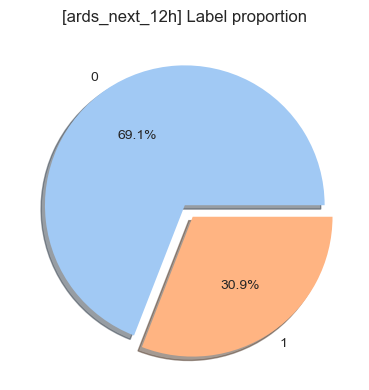

In [28]:
label_cols = ['ards_next_12h'] 

n_labels = len(label_cols)
n_cols = int(np.ceil(np.sqrt(n_labels)))
n_rows = int(np.ceil(n_labels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()  

for ax, col in zip(axes, label_cols):
    vc = preprocessed_df[col].value_counts(dropna=False)

    explode = [0] * len(vc)
    if len(vc) > 1:
        explode[-1] = 0.1  

    ax.pie(
        vc.values,
        labels=vc.index,
        autopct='%1.1f%%',
        explode=explode,
        shadow=True,
        colors=sns.color_palette('pastel')[:len(vc)]
    )
    ax.set_title(f'[{col}] Label proportion')

plt.tight_layout()
plt.show()

In [29]:
# Labeling에 사용한 Annotation은 삭제 후 저장
annot_list = ['pf_ratio', 'ards_now']

preprocessed_df.drop(columns = annot_list).to_csv('preprocessed_df_with_label.csv', index = False)

## 데이터 분할

In [30]:
# loading python modules and set configuration
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import copy
import torch
import os
import pickle
import torch.nn as nn


from functools import partial
from tqdm import tqdm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from typing import Callable, Union
from torch.utils.data import Dataset
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score,
                             precision_recall_curve, auc)

pd.set_option('display.max_columns', None)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=pd.errors.DtypeWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-whitegrid')
cmap_name = 'plasma'

In [31]:
# part1에서 전처리 하였던 데이터셋 가져오기
preprocessed_df = pd.read_csv('preprocessed_df_with_label.csv')

# 앞서 본 실습에서는 여러 label중 12시간 이후의 ards가 발병하는지 아닌지에 대한 label에 대한 실습을 수행.
prediction_label = 'ards_next_12h'

# 이전 전처리에서 설정한 6시간 단위의 Resampling Time을 그대로 활용.
RESAMPLING_TIME = 21600 # 6-hour resampling

In [32]:
import json

# 1. JSON 파일에서 split 정보 로드
with open('split_stay_id.json', 'r') as f:
    splits_info = json.load(f)

# 2. split
train_df = preprocessed_df[preprocessed_df['stay_id'].isin(splits_info['train'])].reset_index(drop=True)
valid_df = preprocessed_df[preprocessed_df['stay_id'].isin(splits_info['valid'])].reset_index(drop=True)
test_df = preprocessed_df[preprocessed_df['stay_id'].isin(splits_info['test'])].reset_index(drop=True)

# 3. 크기 출력 (확인용)
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

splits = {
    'trn_data': train_df,
    'val_data': valid_df,
    'tst_data': test_df,
}

Train: (55266, 228)
Valid: (6906, 228)
Test : (6912, 228)


In [33]:
# 중복된 stay_id가 없는지 검사

set(train_df['stay_id']) & set(valid_df['stay_id'])  # → 빈 집합이어야 함
set(train_df['stay_id']) & set(test_df['stay_id'])   # → 빈 집합이어야 함
set(valid_df['stay_id']) & set(test_df['stay_id'])   # → 빈 집합이어야 함

set()

# normalization

In [48]:
df = pd.read_csv('preprocessed_df_with_label.csv')
print(df.columns.tolist())

['stay_id', 'timestamp', 'SOFA', 'Survival', 'In-hospital_death', 'los', 'ICUType', 'MechVent', 'Height', 'Gender', 'Age', 'first_ALP', 'first_ALT', 'first_AST', 'first_Albumin', 'first_BUN', 'first_Bilirubin', 'first_Cholesterol', 'first_Creatinine', 'first_DiasABP', 'first_FiO2', 'first_GCS', 'first_Glucose', 'first_HCO3', 'first_HCT', 'first_HR', 'first_K', 'first_Lactate', 'first_MAP', 'first_Mg', 'first_NIDiasABP', 'first_NIMAP', 'first_NISysABP', 'first_Na', 'first_PaCO2', 'first_PaO2', 'first_Platelets', 'first_RespRate', 'first_SaO2', 'first_SysABP', 'first_Temp', 'first_TroponinI', 'first_TroponinT', 'first_Urine', 'first_WBC', 'first_Weight', 'first_pH', 'last_ALP', 'last_ALT', 'last_AST', 'last_Albumin', 'last_BUN', 'last_Bilirubin', 'last_Cholesterol', 'last_Creatinine', 'last_DiasABP', 'last_FiO2', 'last_GCS', 'last_Glucose', 'last_HCO3', 'last_HCT', 'last_HR', 'last_K', 'last_Lactate', 'last_MAP', 'last_Mg', 'last_NIDiasABP', 'last_NIMAP', 'last_NISysABP', 'last_Na', 'las

In [34]:
all_cols = preprocessed_df.columns.tolist()

# Category/ID/timestamp
etc_cols = ['stay_id', 'timestamp', 'Gender', 'ICUType', 'MechVent', 'SOFA', 
            'Survival', 'In-hospital_death', 'los']
# Outcome labels
label_cols = ['ards_next_12h']

excl_cols = list(set(etc_cols + label_cols))
incl_cols = [c for c in all_cols if c not in excl_cols]

In [35]:
def min_max_scaling(splits, incl_cols):
    _splits = copy.deepcopy(splits)
    _excl_cols = []

    # Train set에서 min/max를 구해놓기
    col_mins = {}
    col_maxs = {}

    for col in incl_cols:
        col_min = _splits['trn_data'][col].min()
        col_max = _splits['trn_data'][col].max()

        # constant column → 스케일링 제외
        if col_min == col_max:
            _excl_cols.append(col)
            continue
        
        col_mins[col] = col_min
        col_maxs[col] = col_max

        # train scaling
        _splits['trn_data'].loc[:, col] = (_splits['trn_data'][col] - col_min) / (col_max - col_min)

    # 실제로 스케일링할 컬럼 목록 갱신
    _incl_cols = [c for c in incl_cols if c not in _excl_cols]

    # val/test scaling (train의 min/max 사용)
    for col in _incl_cols:
        _splits['val_data'].loc[:, col] = (_splits['val_data'][col] - col_mins[col]) / (col_maxs[col] - col_mins[col])
        _splits['tst_data'].loc[:, col] = (_splits['tst_data'][col] - col_mins[col]) / (col_maxs[col] - col_mins[col])

    return _splits

In [36]:
def standardization(splits, incl_cols):
    _splits = copy.deepcopy(splits)
    _excl_cols = []

    col_means = {}
    col_stds = {}

    for col in incl_cols:
        col_mean = _splits['trn_data'][col].mean()
        col_std = _splits['trn_data'][col].std()

        # constant or zero std → 제외
        if col_std == 0:
            _excl_cols.append(col)
            continue

        col_means[col] = col_mean
        col_stds[col] = col_std

        # train scaling
        _splits['trn_data'].loc[:, col] = (_splits['trn_data'][col] - col_mean) / col_std

    # 실제 scaling 대상 컬럼 갱신
    _incl_cols = [c for c in incl_cols if c not in _excl_cols]

    # val/test scaling using train mean/std
    for col in _incl_cols:
        _splits['val_data'].loc[:, col] = (_splits['val_data'][col] - col_means[col]) / col_stds[col]
        _splits['tst_data'].loc[:, col] = (_splits['tst_data'][col] - col_means[col]) / col_stds[col]

    return _splits

In [37]:
minmax_splits = min_max_scaling(splits, incl_cols)
std_splits = standardization(splits, incl_cols)

##  ML model

In [38]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

from sklearn.preprocessing import MinMaxScaler as mm_scaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

In [63]:
import sklearn, lightgbm, xgboost
print('sklearn: ', sklearn.__version__)
print('lightgbm: ', lightgbm.__version__)
print('xgboost: ', xgboost.__version__)

sklearn:  1.6.1
lightgbm:  4.6.0
xgboost:  3.1.2


In [64]:
excl_cols = label_cols + ['stay_id', 'timestamps','Survival', 'In-hospital_death', 'los'] # 학습에서 제외될 column들  
X_cols = [col for col in preprocessed_df.columns if col not in excl_cols]

In [65]:
def conf_mat(true, pred):
    tp = ((pred == 1) & (true == 1)).sum()
    fp = ((pred == 1) & (true == 0)).sum()
    fn = ((pred == 0) & (true == 1)).sum()
    tn = ((pred == 0) & (true == 0)).sum()
    return tp, fp, fn, tn


def ml_training_evaluation(
    splits: dict,
    seed: int,
    model_name: str,
    X_cols: list,
    eval_split: str,   # 'val' 또는 'test'
    cutoffs: np.array = np.round(np.arange(0.01, 1, 0.01), 2)
):
    """
    splits: {'trn_data': df, 'val_data': df, 'test_data': df, ...}
    seed:   랜덤 시드
    model_name: 'xgb', 'lgb', 'rf', 'lr', 'dt', 'nb' 등
    X_cols: feature 컬럼 리스트
    eval_split: 평가용 데이터셋 이름 ('val', 'test' 등)
    cutoffs: threshold 리스트 (기본 0.01 ~ 0.99)
    """

    # 1. 모델 
    if model_name == 'xgb':
        model = XGBClassifier(
            n_estimators=500,
            learning_rate=0.2,
            max_depth=4,
            random_state=seed,
            eval_metric='logloss'
        )

    elif model_name == 'lgb':
        model = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.2,
            max_depth=4,
            boost_from_average=False,
            random_state=seed
        )

    elif model_name == 'rf':
        model = RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            random_state=seed
        )

    elif model_name == 'lr':
        # 수렴 문제 줄이려고 solver/iter 조정
        model = LogisticRegression(
            random_state=seed,
            max_iter=2000,
            solver='liblinear'
        )

    elif model_name == 'dt':
        model = DecisionTreeClassifier(
            min_samples_split=20,
            random_state=seed
        )
        
    elif model_name == 'nb':
        # 연속형 + 음수 허용 NB
        model = MultinomialNB()
        
    else:
        raise ValueError(f"알 수 없는 model_name: {model_name}")

    # 2. 학습/평가 데이터 준비
    trn_X = splits['trn_data'][X_cols].copy()
    trn_y = splits['trn_data'][prediction_label]

    eval_X = splits[f'{eval_split}_data'][X_cols].copy()
    true = splits[f'{eval_split}_data'][prediction_label]

    # NaN 처리: train 평균으로 채워서 동일하게 적용
    col_means = trn_X.mean()
    trn_X = trn_X.fillna(col_means)
    eval_X = eval_X.fillna(col_means)

    # 타깃 NaN 제거 (실제로는 거의 없겠지만 안전차원)
    not_nan_idx = trn_y.notna()
    trn_X = trn_X[not_nan_idx]
    trn_y = trn_y[not_nan_idx]

    # 3. 학습
    model.fit(trn_X, trn_y)

    # 4. 예측 확률 계산
    # sgd는 predict_proba가 없을 수도 있으므로 별도 처리
    if model_name == 'sgd' and not hasattr(model, "predict_proba"):
        # decision_function 값을 sigmoid로 확률화
        decision = model.decision_function(eval_X)
        prob = 1 / (1 + np.exp(-decision))
    else:
        prob = model.predict_proba(eval_X)[:, 1]

    # 5. AUROC / AUPRC
    auroc = roc_auc_score(true, prob)
    auprc = average_precision_score(true, prob)

    eval_result = []

    # 6. cutoff별 지표 계산
    for cf in cutoffs:
        tmp_eval_result = [model_name, cf]

        pred = np.where(prob > cf, 1, 0)

        tp, fp, fn, tn = conf_mat(true, pred)

        tpr = tp / (tp + fn) if (tp + fn) != 0 else 0        # sensitivity / recall
        ppv = tp / (tp + fp) if (tp + fp) != 0 else 0        # precision
        f1 = 2 * tp / (fp + 2 * tp + fn) if (fp + 2 * tp + fn) != 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) != 0 else 0        # specificity

        tmp_eval_result += [auroc, auprc, tpr, ppv, f1, tnr]
        eval_result.append(tmp_eval_result)

    return pd.DataFrame(
        eval_result,
        columns=['model', 'cutoff', 'auroc', 'auprc', 'tpr', 'ppv', 'f1', 'tnr']
    )


In [66]:
SEED = 42
model_names = ['xgb', 'lgb', 'rf', 'lr', 'dt', 'nb']
eval_dfs = [
    ml_training_evaluation(minmax_splits, SEED, mdl, X_cols, eval_split='val')
    for mdl in model_names
]
eval_dfs = pd.concat(eval_dfs)

# 모델별 AUROC/AUPRC 한 줄 요약
eval_dfs.groupby('model')[['auroc', 'auprc']].first()

[LightGBM] [Info] Number of positive: 16970, number of negative: 38296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021488 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36813
[LightGBM] [Info] Number of data points in the train set: 55266, number of used features: 222
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,auroc,auprc
model,,
dt,0.846115,0.702447
lgb,0.934171,0.866958
lr,0.921995,0.836706
nb,0.826414,0.599784
rf,0.923695,0.856345
xgb,0.935761,0.869810


Evaluating xgb...
Evaluating lgb...
[LightGBM] [Info] Number of positive: 16970, number of negative: 38296
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36813
[LightGBM] [Info] Number of data points in the train set: 55266, number of used features: 222
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

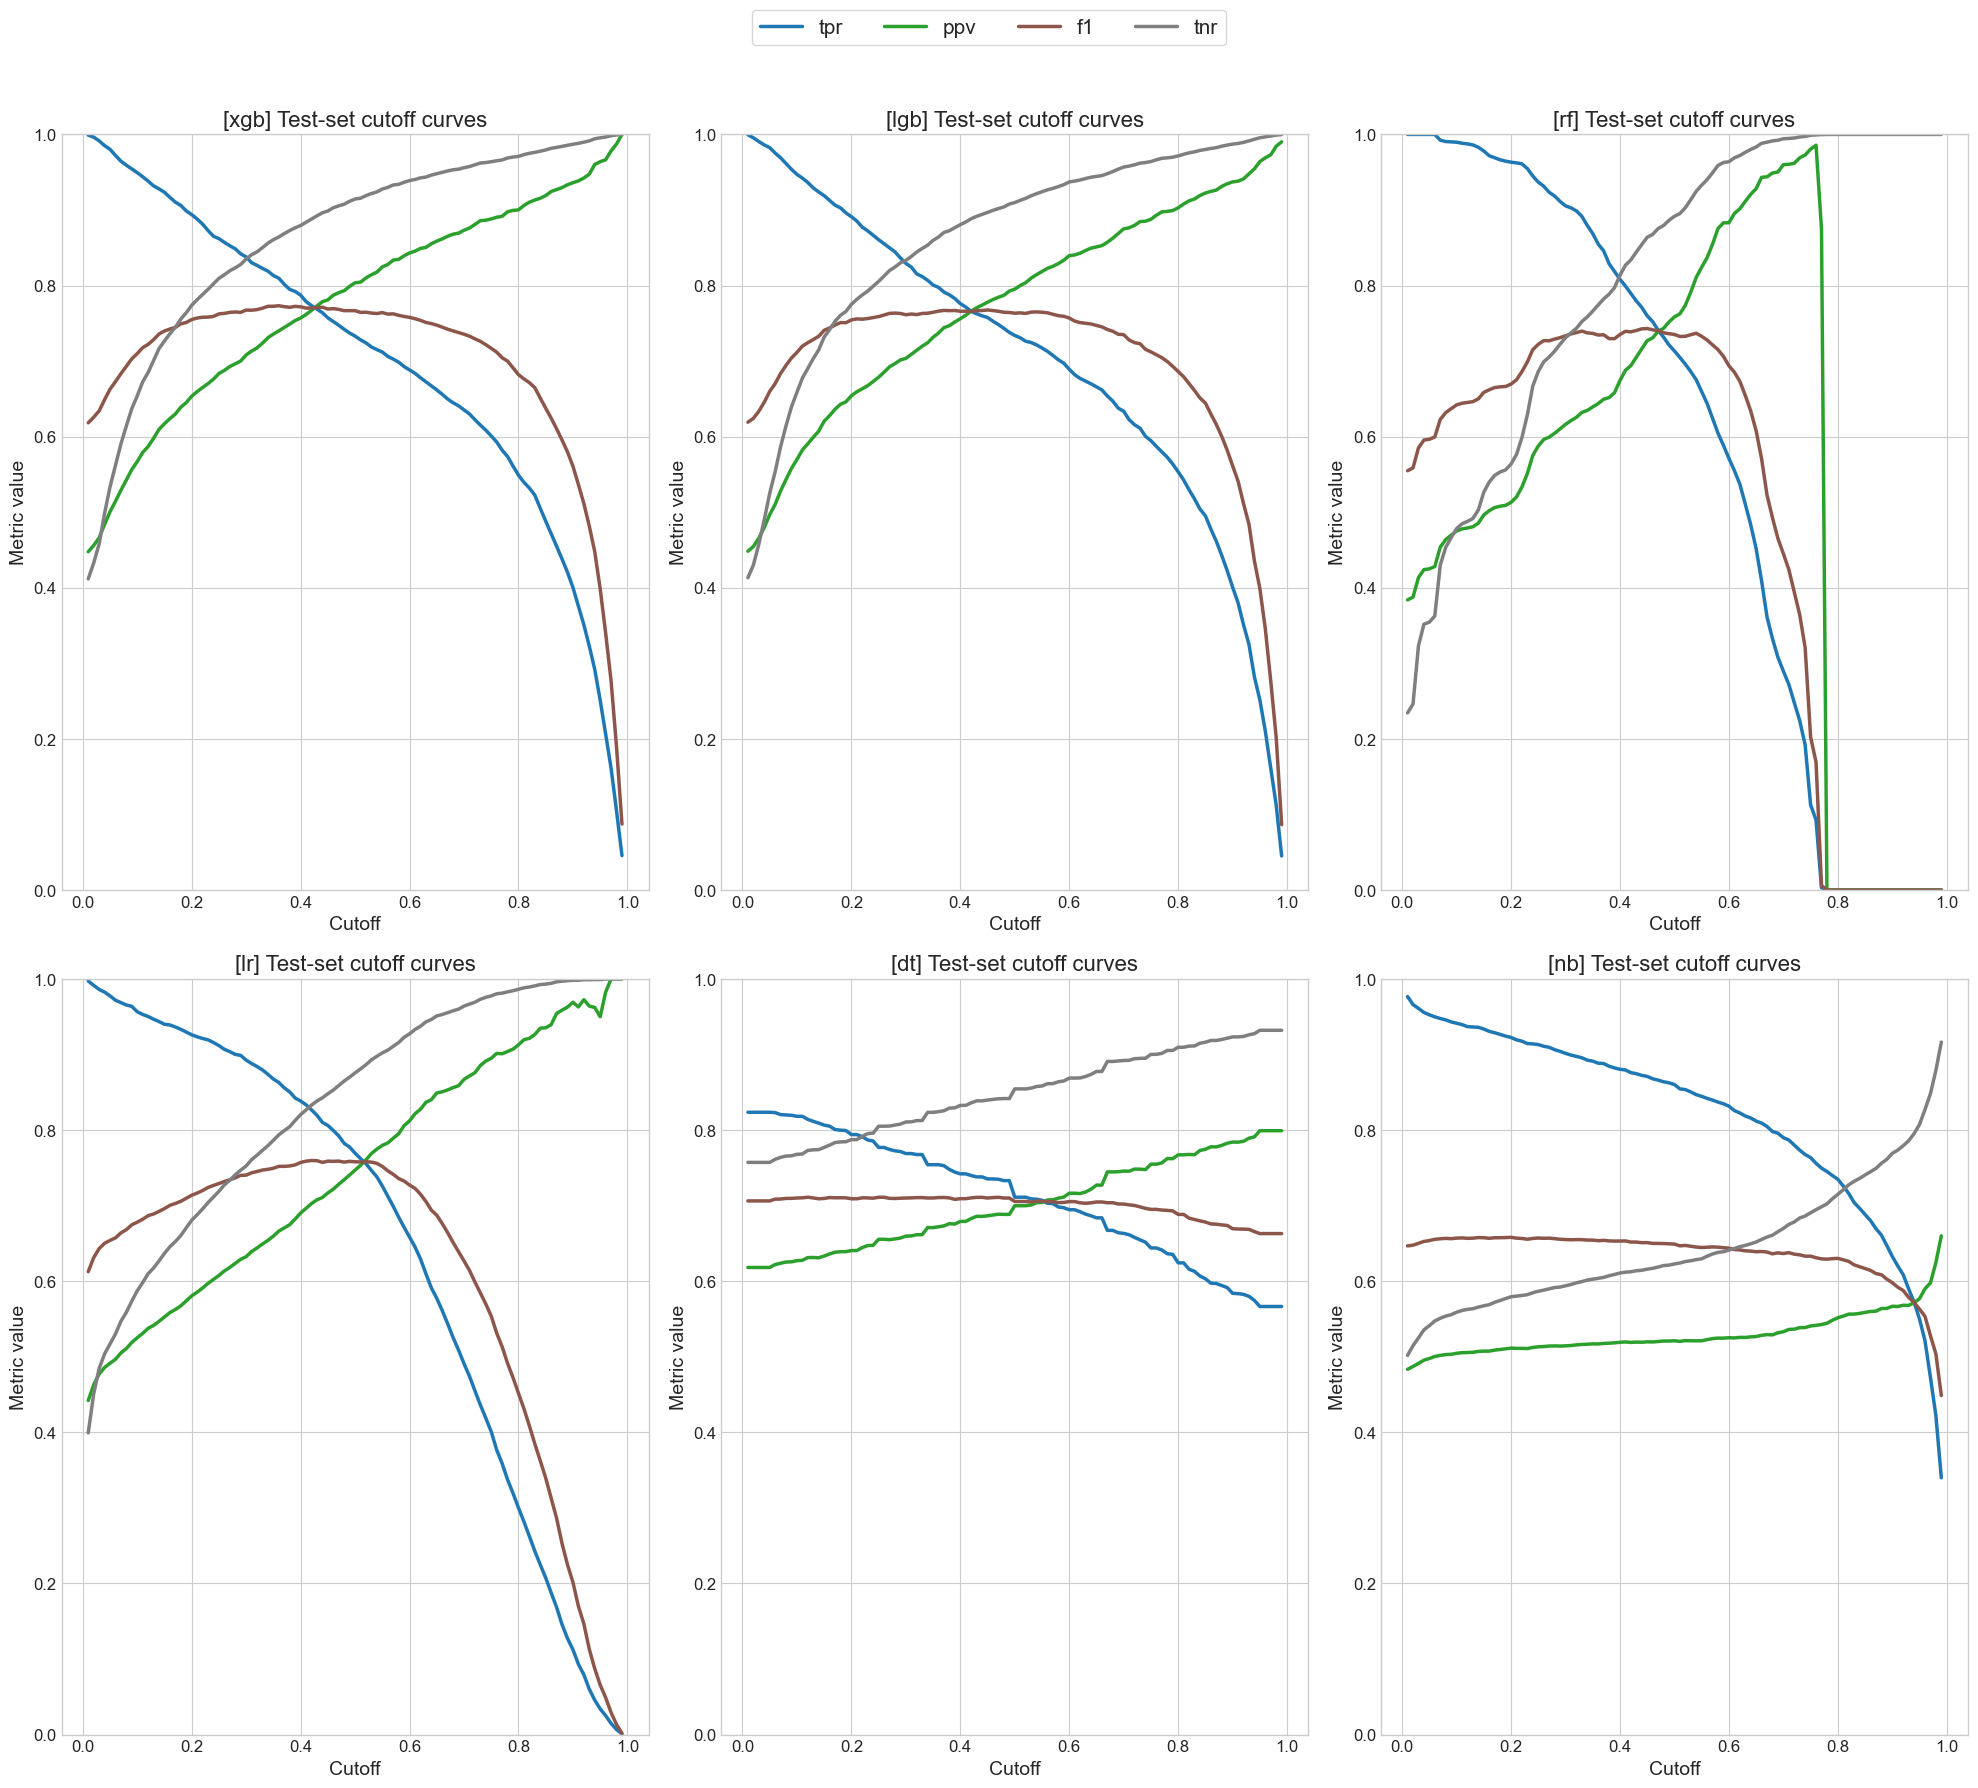

In [67]:
# 평가할 모델 목록(전체)
model_names = ['xgb', 'lgb', 'rf', 'lr', 'dt', 'nb']

# 테스트 성능 저장
tst_results = {}

# 모든 모델을 test-set으로 평가
for mdl in model_names:
    print(f"Evaluating {mdl}...")
    tst_results[mdl] = ml_training_evaluation(
        minmax_splits,
        SEED,
        mdl,
        X_cols,
        eval_split='tst'
    )

# 그래프 9개 그리기
eval_metrics = ['tpr', 'ppv', 'f1', 'tnr']
cmap_name = 'tab10'
cmap = plt.colormaps.get_cmap(cmap_name)

# subplot grid 자동 계산
n_models = len(model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18))
axes = axes.flatten()

plt.rc('font', size=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

for idx, mdl in enumerate(model_names):
    ax = axes[idx]
    df = tst_results[mdl]

    # cutoff vs metric curve
    for m_idx, mtr in enumerate(eval_metrics):
        ax.plot(
            df['cutoff'],
            df[mtr],
            label=mtr,
            color=cmap(m_idx / len(eval_metrics)),
            linewidth=2.5
        )
    ax.set_title(f"[{mdl}] Test-set cutoff curves", fontsize=16)
    ax.set_xlabel("Cutoff")
    ax.set_ylabel("Metric value")
    ax.set_ylim(0, 1)

# 나머지 빈 subplot 삭제
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# 하나의 범례(공통)
fig.legend(
    eval_metrics,
    fontsize=15,
    loc='upper center',
    ncol=4,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### *cutoff: 모델 예측값이 cutoff 값보다 크면 1, 이니면 0으로 결정하게 하는 기준. 이 값에 따라 모델 성능이 달라짐.
##### tpr: true positive rate(민감도)-> 높으면 환자 감지율이 높은 것
##### ppv: positive predictive value(정밀도)-> 높으면 false alarm이 적은 것
##### f1: f1-score-> 높으면 precision과 recall이 균형있게 높음
##### tnr: true negative rate(특이도): 높으면 문제 없는 환자를 정상으로 잘 분류하는것(false alarm이 적음)


## DL model

In [44]:
# 1. 각 stay_id별 sequence 길이 확인 (timestamp 사용!)
display(preprocessed_df.groupby('stay_id')['timestamp'].max().describe())

# 2. 사용할 sequence length 설정 (예: 48시간 → 6시간 resampling이라면 8 step)
preprocessed_df['timestamp'] = preprocessed_df['timestamp'] + 1
SEQ_LEN = 6

# timestamp(=step index)가 SEQ_LEN 이상 존재하는 stay만 사용
ts_stayids = (
    preprocessed_df
    .groupby('stay_id', as_index=False)[['timestamp']]
    .max()
    .query('timestamp >= @SEQ_LEN')['stay_id']
    .unique()
)

print(f"Sequence Length가 {SEQ_LEN} 이상인 stay_id | "
      f"raw : {preprocessed_df.stay_id.nunique()}개 -> {len(ts_stayids)}개")

# 3. 이 stay_id들에 대해, 각 stay당 timestamp 1~SEQ_LEN까지만 남김
timeseries_df = (
    preprocessed_df[
        (preprocessed_df['stay_id'].isin(ts_stayids)) &
        (preprocessed_df['timestamp'] <= SEQ_LEN)
    ]
    .reset_index(drop=True)
)

# 모든 stay_id의 최대 timestamp가 SEQ_LEN인지 확인
display(timeseries_df.groupby('stay_id')['timestamp'].max().describe())

count    11514.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
Name: timestamp, dtype: float64

Sequence Length가 6 이상인 stay_id | raw : 11514개 -> 11514개


count    11514.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: timestamp, dtype: float64

In [45]:
prediction_label = 'ards_next_12h'

# 1. JSON 파일에서 split 정보 로드
with open('split_stay_id.json', 'r') as f:
    splits_info = json.load(f)

# 2. SEQ_LEN 조건을 만족하는 stay_id들만 각각의 split에 교집합으로 사용
train_ids = set(splits_info['train']) & set(ts_stayids)
valid_ids = set(splits_info['valid']) & set(ts_stayids)
test_ids  = set(splits_info['test'])  & set(ts_stayids)

ts_splits = {
    'trn_data': timeseries_df[timeseries_df['stay_id'].isin(train_ids)].reset_index(drop=True),
    'val_data': timeseries_df[timeseries_df['stay_id'].isin(valid_ids)].reset_index(drop=True),
    'tst_data': timeseries_df[timeseries_df['stay_id'].isin(test_ids)].reset_index(drop=True),
}

print("Train seq stays:", ts_splits['trn_data']['stay_id'].nunique())
print("Valid seq stays:", ts_splits['val_data']['stay_id'].nunique())
print("Test  seq stays:", ts_splits['tst_data']['stay_id'].nunique())

Train seq stays: 9211
Valid seq stays: 1151
Test  seq stays: 1152


In [46]:
all_cols = preprocessed_df.columns.tolist()

# 1) scaling에서 제외할 컬럼들
label_cols = ['ards_next_12h', 'SOFA', 'Survival', 'In-hospital_death', 'los']
id_time_cols = ['stay_id', 'timestamp']
cat_cols = ['Gender', 'ICUType', 'MechVent']

excl_cols = label_cols + id_time_cols + cat_cols

# 실제 존재하는 것만 필터링 (오타 방지)
excl_cols = [c for c in excl_cols if c in all_cols]

# 2) scaling에 포함할 컬럼들
incl_cols = [c for c in all_cols if c not in excl_cols]

print("제외(excl_cols):", excl_cols)
print("스케일링 대상(incl_cols) 개수:", len(incl_cols))

제외(excl_cols): ['ards_next_12h', 'SOFA', 'Survival', 'In-hospital_death', 'los', 'stay_id', 'timestamp', 'Gender', 'ICUType', 'MechVent']
스케일링 대상(incl_cols) 개수: 218


In [47]:
minmax_ts_splits = min_max_scaling(ts_splits, incl_cols)

In [48]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

class TS_MIMIC_Dataset(Dataset):
    def __init__(self, df: pd.DataFrame, X_cols: list, label_cols: list,
                 label: str = 'ards_next_12h', seq_len: int = 5):
        """
        df        : 시계열 데이터로 만들 데이터프레임 (한 split: train/val/test)
        X_cols    : X_feature로 사용할 변수 리스트
        label_cols: 기존 데이터프레임에 존재하는 label 변수들 (현재 코드에서는 직접 사용X)
        label     : label_cols 중 사용할 label 이름 (기본: 'ards_next_12h')
        seq_len   : 설정한 시계열 데이터의 길이 (예: 5 step)

        ※ 시계열 데이터를 만들 때 유의할 점 ※
        - label은 설정한 sequence length 이후 시점을 의미해야 함.
          여기서는 각 timestamp에서의 label이 "향후 12시간 이내 ARDS 발생 여부"라서,
          timestamp == seq_len 인 row의 label 값을 해당 sequence의 Y로 사용.
        """
        super(TS_MIMIC_Dataset, self).__init__()

        self.df = df
        self.X_cols = X_cols
        self.label_cols = label_cols
        self.label = label
        self.seq_len = seq_len

        # 시계열 데이터 (X) 만들기: (N, T, C)
        X_data = self.reshape_data_matrix()

        # Label은 sequence length와 동일한 timestamp 시점의 label 사용
        # timestamp == seq_len 인 row만 모아서 stay_id별 label 벡터 생성
        y_data = (
            self.df[self.df['timestamp'] == self.seq_len]
            .groupby('stay_id')[self.label]
            .mean()
            .values
        )

        # Tensor 변환: X는 float, y는 long
        self.X_data = torch.from_numpy(X_data).float()   # (N, T, C)
        self.y_data = torch.from_numpy(y_data).long()    # (N,)

        print(f'Input X, Y Shape : {self.X_data.shape}, {self.y_data.shape}')
        print(f'Unique values of the label: {np.unique(y_data)}')
        print('=================')

        # 만약 univariate time series (C=1) 형태라면 차원 하나 추가
        if len(self.X_data.shape) < 3:
            self.X_data = self.X_data.unsqueeze(2)  # (N, T) → (N, T, 1)

        self.len = self.X_data.shape[0]

    def reshape_data_matrix(self):
        """
        df를 (N, T, C) 형태의 numpy array로 변환
        - N: stay 수
        - T: seq_len (예: 5)
        - C: feature 수 (len(X_cols))
        """
        # stay_id, timestamp 기준 정렬
        df = self.df.sort_values(['stay_id', 'timestamp'])

        # 각 (stay_id, timestamp)에서 X_cols의 값을 사용
        grouped_df = df.groupby(['stay_id', 'timestamp'])[self.X_cols].mean()

        # N은 df에 포함된 고유 stay_id 수
        n_stays = self.df['stay_id'].nunique()
        n_feats = len(self.X_cols)

        # 값들을 (N, T, C)로 reshape
        result = grouped_df.values.reshape(n_stays, self.seq_len, n_feats)

        return result

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

    def __len__(self):
        return self.len


def data_generator(data_dict: dict, X_cols: list, label_cols: list,
                   label: str = 'ards_next_12h', seq_len: int = 5, batch_size: int = 16):
    """
    data_dict : {'trn_data', 'val_data', 'tst_data'}를 가진 dict
    X_cols    : Input feature로 사용될 변수 리스트
    label_cols: 전체 label 변수 리스트 (현재 직접 사용X)
    label     : 사용할 label 이름 (기본: 'ards_next_12h')
    seq_len   : Input Sequence Length (예: 5)
    batch_size: DataLoader batch size
    """

    # Build datasets
    train_dataset = TS_MIMIC_Dataset(data_dict['trn_data'], X_cols, label_cols, label, seq_len)
    valid_dataset = TS_MIMIC_Dataset(data_dict['val_data'], X_cols, label_cols, label, seq_len)
    test_dataset  = TS_MIMIC_Dataset(data_dict['tst_data'], X_cols, label_cols, label, seq_len)

    # Build Dataloaders
    train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                               batch_size=batch_size,
                                               shuffle=False)  # 필요하면 True로 변경
    valid_loader = torch.utils.data.DataLoader(dataset=valid_dataset,
                                               batch_size=batch_size,
                                               shuffle=False)
    test_loader  = torch.utils.data.DataLoader(dataset=test_dataset,
                                               batch_size=batch_size,
                                               shuffle=False)

    return train_loader, valid_loader, test_loader

In [49]:
# X_cols와 label_cols 확인.
excl_cols = label_cols + ['stay_id', 'timestamp','Survival', 'In-hospital_death', 'los'] # 학습에서 제외될 column들  
X_cols = [col for col in preprocessed_df.columns if col not in excl_cols]

BATCH_SIZE = 16 # 본 실습에선 batch size를 16으로 설정.
train_loader, valid_loader, test_loader = data_generator(minmax_ts_splits, X_cols, label_cols, 'ards_next_12h', SEQ_LEN, BATCH_SIZE)

for batch in train_loader:
    print(f'Input Shape of each mini-batch : {batch[0].shape} / Label Shape of each mini-batch : {batch[1].shape}')
    break

Input X, Y Shape : torch.Size([9211, 6, 221]), torch.Size([9211])
Unique values of the label: [0. 1.]
Input X, Y Shape : torch.Size([1151, 6, 221]), torch.Size([1151])
Unique values of the label: [0. 1.]
Input X, Y Shape : torch.Size([1152, 6, 221]), torch.Size([1152])
Unique values of the label: [0. 1.]
Input Shape of each mini-batch : torch.Size([16, 6, 221]) / Label Shape of each mini-batch : torch.Size([16])


In [51]:
class LSTMClassifier(nn.Module):
    def __init__(self,
                 input_dim: int = 221,      # 너의 feature 개수
                 hidden_dim: int = 128,
                 num_layers: int = 3,
                 num_classes: int = 2,     # binary classification
                 dropout: float = 0.1):
        """
        input_dim : feature dimension (총 221개)
        hidden_dim: LSTM hidden size
        num_layers: stacked LSTM layer 수
        num_classes: output 클래스 수 (binary = 2)
        dropout   : LSTM 층 사이 dropout 비율
        """
        super(LSTMClassifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM 정의
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # 마지막 hidden state → 최종 분류
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        x shape: (batch, seq_len=6, feature_dim=221)
        """
        batch_size = x.size(0)
        device = x.device

        # 초기 hidden & cell state
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)

        # LSTM Forward
        out, _ = self.lstm(x, (h0, c0))  
        # out: (batch, seq_len=6, hidden_dim)

        # 마지막 타임스텝 출력 사용 (timestamp=6)
        out_last = out[:, -1, :]         # shape: (batch, hidden_dim)

        # 최종 클래스 로짓
        logits = self.fc(out_last)       # shape: (batch, num_classes)

        return logits

In [52]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 6):
        """
        Positional Encoding for sequence length 6
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)                      # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)   # even index
        pe[:, 1::2] = torch.cos(position * div_term)   # odd index

        pe = pe.unsqueeze(1)  # (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (seq_len, batch, d_model)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


class TransformerClassifier(nn.Module):
    def __init__(self,
                 input_dim: int = 221,       
                 d_model: int = 128,
                 n_head: int = 4,
                 num_encoder_layers: int = 3,
                 dim_feedforward: int = 256,
                 num_classes: int = 2,
                 dropout: float = 0.1,
                 max_seq_length: int = 6):   
        """
        Transformer 기반 시계열 분류 모델
        """
        super().__init__()

        self.d_model = d_model

        # (feature_dim → d_model) 임베딩
        self.embedding = nn.Linear(input_dim, d_model)

        # Positional Encoding (길이 6에 맞춤)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len=max_seq_length)

        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False  # Transformer 기본 형태 유지
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers
        )

        # Classification Head
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, src):
        """
        src shape: (batch_size, seq_len=6, feature_dim=221)
        """
        # 1) Linear projection to d_model
        src = self.embedding(src)   # (batch, seq_len, d_model)

        # 2) Transformer 입력 형태로 변경: (seq_len, batch, d_model)
        src = src.transpose(0, 1)

        # 3) Add positional encoding
        src = self.pos_encoder(src)

        # 4) Transformer Encoder
        output = self.transformer_encoder(src)   # (seq_len, batch, d_model)

        # 5) Sequence → 하나의 벡터로 요약 (mean pooling)
        out = output.mean(dim=0)     # (batch, d_model)

        # 6) Linear classification layer
        logits = self.fc(out)        # (batch, num_classes)
        return logits

In [53]:
# 딥러닝 학습 시 사용할 device 할당.
print(f'Is the GPU available? : {torch.cuda.is_available()}')
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# X_cols는 이전 단계에서 다음처럼 생성됨:
# X_cols = [col for col in preprocessed_df.columns if col not in excl_cols]
# 따라서 input_dim은 len(X_cols)
INPUT_DIM = len(X_cols)  # 자동 설정 → 221이 들어감

print(f"Input feature dimension: {INPUT_DIM}")

# LSTM MODEL
model = LSTMClassifier(
            input_dim=INPUT_DIM,
            hidden_dim=128,
            num_layers=3,
            num_classes=2,         # binary classification
            dropout=0.1
        ).to(DEVICE)

Is the GPU available? : False
Input feature dimension: 221


In [54]:
def train(model, train_loader, valid_loader, optimizer, criterion, scheduler, configs, device):
    """
    model     : PyTorch model (이미 device로 올려둔 상태 권장)
    train_loader, valid_loader : DataLoader
    optimizer : torch.optim.*
    criterion : loss function (예: nn.CrossEntropyLoss)
    scheduler : lr scheduler or None
    configs   : dict (epochs, result_dir, model_type, early_stop, patience 등)
    device    : 'cpu'  (현재 너는 CPU만 사용)
    """

    # 결과 저장 폴더 생성
    ckpt_dir = os.path.join(configs['result_dir'], 'checkpoint')
    os.makedirs(ckpt_dir, exist_ok=True)

    best_valid_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(configs['epochs']):
        model.train()
        running_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{configs['epochs']} - Training"):
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device).long()   # CrossEntropyLoss 대비

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / max(1, len(train_loader))

        # ---- Validation ----
        valid_loss, valid_acc, valid_precision, valid_recall, valid_f1, valid_auroc, valid_auprc = evaluate(
            model, valid_loader, criterion, device
        )

        # ---- Scheduler ----
        if scheduler is not None:
            # ReduceLROnPlateau는 metric을 인자로 받음
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(valid_loss)
            else:
                scheduler.step()

        print(f"=== Epoch {epoch+1}/{configs['epochs']} | "
              f"Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f} ===")

        try:
            print(f"Valid Acc: {valid_acc:.4f} | Precision: {valid_precision:.4f} "
                  f"| Recall: {valid_recall:.4f} | F1: {valid_f1:.4f}")
            print(f"AUROC: {valid_auroc:.4f} | AUPRC: {valid_auprc:.4f}")
        except Exception:
            # auroc/auprc가 None일 때 대비
            print(f"Valid Acc: {valid_acc} | Precision: {valid_precision} "
                  f"| Recall: {valid_recall} | F1: {valid_f1}")
            print(f"AUROC: {valid_auroc} | AUPRC: {valid_auprc}")
        print('=================')

        # ---- Early Stopping ----
        if configs.get('early_stop', False):
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                early_stop_counter = 0
                torch.save(
                    model.state_dict(),
                    os.path.join(ckpt_dir, f"Best_{configs['model_type']}.pt")
                )
            else:
                early_stop_counter += 1
                if early_stop_counter >= configs.get('patience', 5):
                    print("== Early stopping triggered. ==")
                    print(f"Best Valid Loss : {best_valid_loss:.4f}")
                    break


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # 예측값 및 확률
            preds = outputs.argmax(dim=1)
            probs = torch.softmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # 이진 분류: positive 클래스(1)의 확률만 사용
            if outputs.shape[1] == 2:
                all_probs.extend(probs[:, 1].cpu().numpy())
            else:
                # multi-class일 경우 전체 확률을 저장
                all_probs.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(data_loader))

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    # AUROC / AUPRC는 이진 분류일 때 all_probs = 양성 클래스 확률로 계산
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auroc = None

    try:
        auprc = average_precision_score(all_labels, all_probs)
    except Exception:
        auprc = None

    return avg_loss, accuracy, precision, recall, f1, auroc, auprc

In [55]:
def inference(model, test_loader, criterion, configs, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Inference"):
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # 예측값 및 확률
            preds = outputs.argmax(dim=1)
            probs = torch.softmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # 이진 분류 → 클래스 1 확률만 저장
            if outputs.shape[1] == 2:
                all_probs.extend(probs[:, 1].cpu().numpy())
            else:
                all_probs.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(test_loader))

    cm = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auroc = None

    try:
        auprc = average_precision_score(all_labels, all_probs)
    except Exception:
        auprc = None

    print(f"Test Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")
    try:
        print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}")
        print(f"AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")
    except Exception:
        print(f"Precision: {precision} | Recall: {recall} | F1 Score: {f1}")
        print(f"AUROC: {auroc} | AUPRC: {auprc}")

    return all_preds, avg_loss, cm, accuracy, precision, recall, f1, auroc, auprc

In [56]:
def fix_seed(seed: int = 383):
    
    import random
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # CPU-only 환경에서는 CUDA / cuDNN 관련 설정 불필요
    # 그래도 아래 옵션은 안전하게 유지 가능 (CUDA 없으면 무시됨)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seed(SEED)

In [57]:
# Training Hyperparameter Config
configs = {
    'optimizer'   : 'AdamW',        # Optimizer 종류
    'epochs'      : 50,             # 최대 Epoch 수
    'lr'          : 1e-4,           # Learning Rate
    'batch_size'  : BATCH_SIZE,     # Batch Size (앞에서 정의한 값 사용)
    'weight_decay': 1e-5,           # L2 정규화 계수
    'scheduler'   : True,           # LR Scheduler 사용 여부
    'T_max'       : 50,             # CosineAnnealingLR 주기 (보통 epochs와 같게 둠)
    'early_stop'  : True,           # Early Stopping 사용 여부
    'patience'    : 10,             # 개선 없을 때 몇 epoch 기다릴지
    'loss_type'   : 'crossentropy', # Loss Function 타입
    'model_type'  : 'LSTM',         # 모델 타입 이름 (체크포인트 파일명 등에 사용)
    'result_dir'  : './result',     # 결과 저장 경로
}

# Optimizer 설정
if configs['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=configs['lr'],
        weight_decay=configs['weight_decay']
    )
else:
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=configs['lr'],
        momentum=0.9,
        weight_decay=configs['weight_decay']
    )

# Learning Rate Scheduler 설정
if configs['scheduler']:
    # 보통 T_max는 전체 epoch 수와 같게 두는 경우가 많음
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=configs['T_max']
    )
else:
    scheduler = None

# Loss Function 설정
if configs['loss_type'] == 'crossentropy':
    criterion = nn.CrossEntropyLoss().to(DEVICE)
else:
    # 필요하면 다른 loss 추가 가능
    raise ValueError(f"Unsupported loss_type: {configs['loss_type']}")

In [58]:
# Training
train(model, train_loader, valid_loader, optimizer, criterion, scheduler, configs, DEVICE)

Epoch 1/50 - Training: 100%|████████████████████████████████████████████████████████| 576/576 [00:05<00:00, 114.23it/s]


=== Epoch 1/50 | Train Loss: 0.4524 | Valid Loss: 0.3477 ===
Valid Acc: 0.8410 | Precision: 0.8047 | Recall: 0.8205 | F1: 0.8117
AUROC: 0.9105 | AUPRC: 0.7854


Epoch 2/50 - Training: 100%|████████████████████████████████████████████████████████| 576/576 [00:04<00:00, 116.88it/s]


=== Epoch 2/50 | Train Loss: 0.3322 | Valid Loss: 0.3062 ===
Valid Acc: 0.8627 | Precision: 0.8292 | Recall: 0.8536 | F1: 0.8394
AUROC: 0.9297 | AUPRC: 0.8312


Epoch 3/50 - Training: 100%|████████████████████████████████████████████████████████| 576/576 [00:04<00:00, 119.30it/s]


...

=== Epoch 27/50 | Train Loss: 0.2360 | Valid Loss: 0.2748 ===
Valid Acc: 0.8931 | Precision: 0.8716 | Recall: 0.8670 | F1: 0.8692
AUROC: 0.9423 | AUPRC: 0.8782


Epoch 28/50 - Training: 100%|███████████████████████████████████████████████████████| 576/576 [00:04<00:00, 120.60it/s]


=== Epoch 28/50 | Train Loss: 0.2353 | Valid Loss: 0.2749 ===
Valid Acc: 0.8931 | Precision: 0.8712 | Recall: 0.8678 | F1: 0.8695
AUROC: 0.9427 | AUPRC: 0.8786


Epoch 29/50 - Training: 100%|███████████████████████████████████████████████████████| 576/576 [00:04<00:00, 119.36it/s]


=== Epoch 29/50 | Train Loss: 0.2332 | Valid Loss: 0.2757 ===
Valid Acc: 0.8931 | Precision: 0.8716 | Recall: 0.8670 | F1: 0.8692
AUROC: 0.9421 | AUPRC: 0.8774
== Early stopping triggered. ==
Best Valid Loss : 0.2724


In [59]:
# Inference / Test
# Checkpoint 경로
ckpt_path = f"{configs['result_dir']}/checkpoint/Best_{configs['model_type']}.pt"

# CPU 환경에서 모델 로드
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

# device 재할당
model.to(DEVICE)
model.eval()

print(f"------- Test Set Results -------")
predictions, avg_loss, cm, acc, prec, rec, f1, auroc, auprc = \
    inference(model, test_loader, criterion, configs, DEVICE)

metrics = {
    "confusion_matrix": cm,
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1,
    "auroc": auroc,
    "auprc": auprc
}

# 저장 경로 생성
perf_dir = f"{configs['result_dir']}/performances"
os.makedirs(perf_dir, exist_ok=True)

# 성능 저장
save_path = f"{perf_dir}/Best_{configs['model_type']}_testset_result.pkl"

with open(save_path, 'wb') as f:
    pickle.dump(metrics, f)

print(f"Test results saved to: {save_path}")

------- Test Set Results -------


Inference: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 532.83it/s]

Test Loss: 0.2802 | Accuracy: 0.8837
Precision: 0.8620 | Recall: 0.8528 | F1 Score: 0.8572
AUROC: 0.9414 | AUPRC: 0.8656
Test results saved to: ./result/performances/Best_LSTM_testset_result.pkl


In [60]:
from pathlib import Path

# 1. Transformer 모델 생성
INPUT_DIM = len(X_cols)   # 현재 feature 개수 (예: 221)
print("Transformer input_dim =", INPUT_DIM)

model = TransformerClassifier(
    input_dim=INPUT_DIM,   
    d_model=128,
    n_head=4,
    num_encoder_layers=3,
    dim_feedforward=256,
    num_classes=2,
    dropout=0.1,
    max_seq_length=SEQ_LEN  # 시퀀스 길이 (예: 6)
).to(DEVICE)


# 2. 하이퍼파라미터 configs
configs = {
    'optimizer'   : 'AdamW',        # Optimizer 
    'epochs'      : 50,             # Training Max Epochs  
    'lr'          : 1e-4,           # Learning Rate   
    'batch_size'  : BATCH_SIZE,     # Batch Size
    'weight_decay': 1e-5,           # Weight Decay  
    'scheduler'   : True,           # Learning Rate Scheduler 사용 여부
    'T_max'       : 50,             # CosineAnnealingLR 주기 (보통 epochs와 동일)
    'early_stop'  : True,           # Early Stopping 사용 여부
    'patience'    : 10,             # Early Stopping patience
    'loss_type'   : 'crossentropy', # Loss Function 타입
    'model_type'  : 'Transformer',  # 모델 타입 이름 (체크포인트 파일명에 사용)
    'result_dir'  : './result',     # 결과 저장 폴더
}

# 3. Optimizer 설정
if configs['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=configs['lr'],
        weight_decay=configs['weight_decay']
    )
else:
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=configs['lr'],
        momentum=0.9,
        weight_decay=configs['weight_decay']
    )

# 4. Scheduler 설정
if configs['scheduler']:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=configs['T_max']
    )
else:
    scheduler = None

# 5. Loss Function 설정
if configs['loss_type'] == 'crossentropy':
    criterion = nn.CrossEntropyLoss().to(DEVICE)
else:
    raise ValueError(f"Unsupported loss_type: {configs['loss_type']}")


# 6. Training
train(
    model,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    scheduler,
    configs,
    DEVICE
)

# 7. Inference (= Evaluation)
ckpt_path = Path(configs['result_dir']) / "checkpoint" / f"Best_{configs['model_type']}.pt"

if not ckpt_path.exists():
    print("체크포인트 파일이 없습니다. 먼저 train()이 제대로 끝났는지 확인하세요.")
    print("찾으려고 한 경로:", ckpt_path)
else:
    # CPU 환경에서 체크포인트 로드
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    print('------- Test Set Results -------')
    predictions, avg_loss, cm, acc, prec, rec, f1, auroc, auprc = \
        inference(model, test_loader, criterion, configs, DEVICE)

    metrics = {
        "confusion_matrix": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "auroc": auroc,
        "auprc": auprc
    }

    # 최종 test set 성능 저장 경로 생성
    perf_dir = Path(configs['result_dir']) / "performances"
    perf_dir.mkdir(parents=True, exist_ok=True)

    save_path = perf_dir / f"Best_{configs['model_type']}_testset_result.pkl"
    with open(save_path, 'wb') as f:
        pickle.dump(metrics, f)

    print(f"Test metrics saved to: {save_path}")

C:\hanijupyter\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Transformer input_dim = 221


Epoch 1/50 - Training: 100%|█████████████████████████████████████████████████████████| 576/576 [00:09<00:00, 57.85it/s]


=== Epoch 1/50 | Train Loss: 0.3954 | Valid Loss: 0.3018 ===
Valid Acc: 0.8697 | Precision: 0.8377 | Recall: 0.8567 | F1: 0.8460
AUROC: 0.9313 | AUPRC: 0.8376


Epoch 2/50 - Training: 100%|█████████████████████████████████████████████████████████| 576/576 [00:10<00:00, 56.96it/s]


...

=== Epoch 24/50 | Train Loss: 0.2293 | Valid Loss: 0.2787 ===
Valid Acc: 0.8940 | Precision: 0.8780 | Recall: 0.8595 | F1: 0.8680
AUROC: 0.9422 | AUPRC: 0.8814


Epoch 25/50 - Training: 100%|████████████████████████████████████████████████████████| 576/576 [00:09<00:00, 58.39it/s]


=== Epoch 25/50 | Train Loss: 0.2262 | Valid Loss: 0.2805 ===
Valid Acc: 0.8914 | Precision: 0.8750 | Recall: 0.8559 | F1: 0.8646
AUROC: 0.9420 | AUPRC: 0.8821
== Early stopping triggered. ==
Best Valid Loss : 0.2650
------- Test Set Results -------


Inference: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 373.04it/s]


Test Loss: 0.2583 | Accuracy: 0.8924
Precision: 0.8728 | Recall: 0.8634 | F1 Score: 0.8679
AUROC: 0.9494 | AUPRC: 0.8967
Test metrics saved to: result\performances\Best_Transformer_testset_result.pkl


In [68]:
# 시계열 딥러닝 성능, ML 모델 성능 비교  
dl_performance_list = []

perf_root = Path("./result/performances")

for model_name in ['LSTM', 'Transformer']:
    with open(perf_root / f"Best_{model_name}_testset_result.pkl", 'rb') as f:
        result = pickle.load(f)
        result['model'] = model_name
        dl_performance_list.append(result)

# DL 결과 DataFrame
eval_dl_df = pd.DataFrame(dl_performance_list)

# ML 결과 + DL 결과 합치기
performance_df = pd.concat(
    [
        eval_dfs[['model', 'auroc', 'auprc']].drop_duplicates(),
        eval_dl_df[['model', 'auroc', 'auprc']]
    ],
    axis=0
).reset_index(drop=True)

display(performance_df)

,model,auroc,auprc
0,xgb,0.935761,0.869810
1,lgb,0.934171,0.866958
2,rf,0.923695,0.856345
3,lr,0.921995,0.836706
4,dt,0.846115,0.702447
5,nb,0.826414,0.599784
6,LSTM,0.941380,0.865641
7,Transformer,0.949389,0.896651


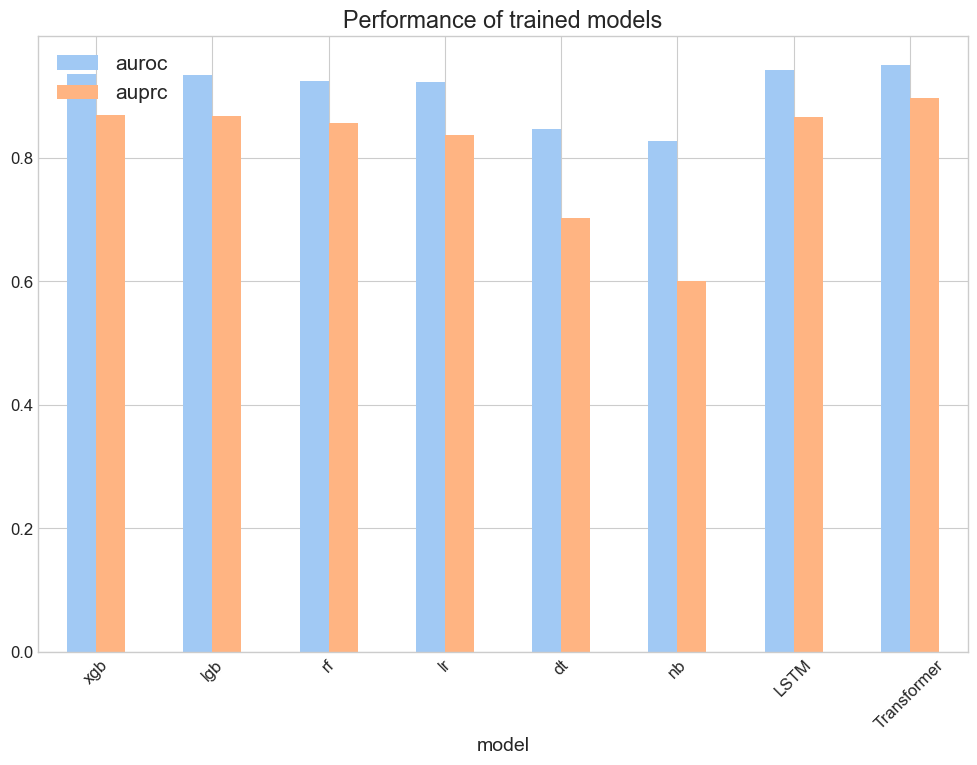

In [69]:
# 모델별 성능 시각화
performance_df.set_index("model")[["auroc", "auprc"]].plot(kind="bar", color = sns.color_palette('pastel'), rot=45, figsize=(12,8))
plt.legend(fontsize=15)
plt.title('Performance of trained models')
plt.show()